# Exercise 3: Normalizing Flows and Invertible Neural Networks

---

## Overview

This notebook implements and evaluates RealNVP (Real-valued Non-Volume Preserving) networks for:
1. Two Moons dataset (unconditional and conditional)
2. Hexagonal Gaussian Mixture Model
3. Higher-dimensional datasets (Digits and MNIST)

---

## Setup and Imports

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Utility Functions

In [47]:
def compute_mmd(x, y, kernel='rbf', sigma=1.0):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()


    
    def rbf_kernel(x, y, sigma):
        xx = np.sum(x**2, axis=1)[:, None]
        yy = np.sum(y**2, axis=1)[None, :]
        xy = x @ y.T
        distances = xx - 2*xy + yy
        return np.exp(-distances / (2 * sigma**2))
    
    if kernel == 'rbf':
        K_xx = rbf_kernel(x, x, sigma)
        K_yy = rbf_kernel(y, y, sigma)
        K_xy = rbf_kernel(x, y, sigma)
    else:  # linear kernel
        K_xx = x @ x.T
        K_yy = y @ y.T
        K_xy = x @ y.T
    n = len(x)
    m = len(y)
    mmd = (K_xx.sum() - np.trace(K_xx)) / (n * (n-1))
    mmd += (K_yy.sum() - np.trace(K_yy)) / (m * (m-1))
    mmd -= 2 * K_xy.sum() / (n * m)
    
    return mmd


def generate_hexagon_gmm(n_samples, radius=1.0, std=0.1, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    
    angles = np.linspace(0, 2*np.pi, 7)[:-1]  # 6 spaced angles
    centers = radius * np.array([[np.cos(a), np.sin(a)] for a in angles])
    
    samples_per_center = n_samples // 6
    X = []
    y = []
    
    for i, center in enumerate(centers):
        # Generate samples from this Gaussian
        samples = np.random.randn(samples_per_center, 2) * std + center
        X.append(samples)
        y.append(np.ones(samples_per_center) * i)
    
    X = np.vstack(X)
    y = np.hstack(y).astype(int)
    
    # Shuffle
    indices = np.random.permutation(len(X))
    
    return X[indices], y[indices]


def plot_samples(X, y=None, title="Data Samples", figsize=(8, 8)):
    plt.figure(figsize=figsize)
    if y is not None:
        scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', alpha=0.6, s=20)
        plt.colorbar(scatter)
    else:
        plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=20)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_code_distribution(codes, title="Code Space Distribution"):

    #Plot histograms and Q-Q plots to check if codes are standard normal.
    if isinstance(codes, torch.Tensor):
        codes = codes.detach().cpu().numpy()
    
    n_dims = min(codes.shape[1], 4)  # Plot at most 4 dimensions
    
    fig, axes = plt.subplots(2, n_dims, figsize=(4*n_dims, 8))
    
    for i in range(n_dims):
        # Histogram
        axes[0, i].hist(codes[:, i], bins=50, density=True, alpha=0.7, label='Data')
        x = np.linspace(-4, 4, 100)
        axes[0, i].plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), 'r-', label='N(0,1)')
        axes[0, i].set_title(f'Dimension {i+1}')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(codes[:, i], dist="norm", plot=axes[1, i])
        axes[1, i].set_title(f'Q-Q Plot Dim {i+1}')
        axes[1, i].grid(True, alpha=0.3)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

---

# Task 1: Two Moons with an Invertible Neural Network

## 1.1 RealNVP Architecture

We implement a RealNVP network consisting of coupling blocks.

In [48]:
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask, condition_size=0):
       
        super().__init__()
        self.mask = mask
        
        # Network to compute translation parameter
        self.translation_net = nn.Sequential(
            nn.Linear(input_size + condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size)
        )
        
        # Network to compute scaling parameter
        self.scaling_net = nn.Sequential(
            nn.Linear(input_size + condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size)
        )
    
    def forward(self, x, condition=None):

        x_masked = x * self.mask
        
        if condition is not None:
            net_input = torch.cat([x_masked, condition], dim=1)
        else:
            net_input = x_masked
        
        t = self.translation_net(net_input)
        s_raw = self.scaling_net(net_input)
        s = torch.tanh(s_raw)  # Bound the scaling
        
        # Apply  only non-masked dimensions
        z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        
        
        log_det = torch.sum((1 - self.mask) * s, dim=1)
        
        return z, log_det
    
    def inverse(self, z, condition=None):
       
        z_masked = z * self.mask

        if condition is not None:
            net_input = torch.cat([z_masked, condition], dim=1)
        else:
            net_input = z_masked
        t = self.translation_net(net_input)
        s_raw = self.scaling_net(net_input)
        s = torch.tanh(s_raw)
        
        # Apply inverse transformation
        x = z_masked + (1 - self.mask) * ((z - t) * torch.exp(-s))
 
        log_det = -torch.sum((1 - self.mask) * s, dim=1)
        
        return x, log_det


class RealNVP(nn.Module):

    def __init__(self, input_size, hidden_size, blocks, condition_size=0):
        super().__init__()
        self.input_size = input_size
        self.condition_size = condition_size
        
        self.coupling_layers = nn.ModuleList()
        self.rotation_matrices = []
        
        for i in range(blocks):
            # Alternate masks
            mask = torch.zeros(input_size)
            mask[:input_size//2] = 1
            if i % 2 == 1:
                mask = 1 - mask
            
            self.coupling_layers.append(
                CouplingLayer(input_size, hidden_size, mask, condition_size)
            )
            
            # Random orthogonal matrix for rotation (except last layer)
            if i < blocks - 1:
                Q, _ = torch.linalg.qr(torch.randn(input_size, input_size))
                self.rotation_matrices.append(Q)
    
    def forward(self, x, condition=None):
      
        z = x
        log_det_sum = 0
        
        for i, layer in enumerate(self.coupling_layers):
            z, log_det = layer(z, condition)
            log_det_sum += log_det
            
            # Apply rotation
            if i < len(self.coupling_layers) - 1:
                z = z @ self.rotation_matrices[i].to(z.device)
        
        return z, log_det_sum
    
    def inverse(self, z, condition=None):
       
        x = z
        log_det_sum = 0
        

        for i in range(len(self.coupling_layers) - 1, -1, -1):
            # Inverse rotation
            if i < len(self.coupling_layers) - 1:
                x = x @ self.rotation_matrices[i].T.to(x.device)
            
            x, log_det = self.coupling_layers[i].inverse(x, condition)
            log_det_sum += log_det
        
        return x, log_det_sum
    
    def sample(self, num_samples, conditions=None):
        self.eval()
        with torch.no_grad():
            if conditions is None:
                z = torch.randn(num_samples, self.input_size).to(next(self.parameters()).device)
                samples, _ = self.inverse(z)
            else:

                # Sample for each condition
                if not isinstance(conditions, torch.Tensor):
                    conditions = torch.tensor(conditions, dtype=torch.float32)
                conditions = conditions.to(next(self.parameters()).device)
                
                num_conditions = conditions.shape[0]
                z = torch.randn(num_conditions * num_samples, self.input_size).to(conditions.device)
                
                # Repeat conditions for each sample
                cond_repeated = conditions.repeat_interleave(num_samples, dim=0)
                
                samples, _ = self.inverse(z, cond_repeated)
        
        return samples.cpu().numpy()



def test_invertibility(model, x, condition=None):
    
    model.eval()
    with torch.no_grad():
        z, _ = model.forward(x, condition)
        x_reconstructed, _ = model.inverse(z, condition)
        error = torch.max(torch.abs(x - x_reconstructed)).item()
        print(f"Maximum reconstruction error: {error:.2e}")
        return error < 1e-5  # Should be very small (numerical precision)



## 1.2 Training Function

In [49]:


def train_inn(model, X_train, X_test=None,epochs=100, batch_size=64, lr=0.001, condition=None, condition_test=None,verbose=True):
    model.train()
    model = model.to(device)
    if not isinstance(X_train, torch.Tensor):
        X_train = torch.tensor(X_train, dtype=torch.float32)
    X_train = X_train.to(device)
    
    if condition is not None:
        if not isinstance(condition, torch.Tensor):
            condition = torch.tensor(condition, dtype=torch.float32)
        condition = condition.to(device)
        dataset = TensorDataset(X_train, condition)
    else:
        dataset = TensorDataset(X_train)
    
    
    if X_test is not None:
        if not isinstance(X_test, torch.Tensor):
            X_test = torch.tensor(X_test, dtype=torch.float32)
        X_test = X_test.to(device)
        
        if condition_test is not None:
            if not isinstance(condition_test, torch.Tensor):
                condition_test = torch.tensor(condition_test, dtype=torch.float32)
            condition_test = condition_test.to(device)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []



    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch in dataloader:
            if condition is not None:
                x_batch, cond_batch = batch
            else:
                x_batch = batch[0]
                cond_batch = None
            
            # Forward pass
            z, log_det = model.forward(x_batch, cond_batch)
    
            log_pz = -0.5 * torch.sum(z**2, dim=1) - 0.5 * z.shape[1] * np.log(2 * np.pi)
            log_px = log_pz + log_det
            loss = -torch.mean(log_px)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_train_loss)
        

        if X_test is not None:
            model.eval() 
            with torch.no_grad():
                
                z_test, log_det_test = model.forward(X_test, condition_test)
                log_pz_test = -0.5 * torch.sum(z_test**2, dim=1) - 0.5 * z_test.shape[1] * np.log(2 * np.pi)
                log_px_test = log_pz_test + log_det_test
                avg_test_loss = -torch.mean(log_px_test).item()
                test_losses.append(avg_test_loss)
        
        if verbose and (epoch + 1) % 10 == 0:
            msg = f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}"
            if X_test is not None:
                msg += f", Test Loss: {avg_test_loss:.4f}"
            print(msg)
    
    return train_losses, test_losses



## 1.3 Two Moons Experiment

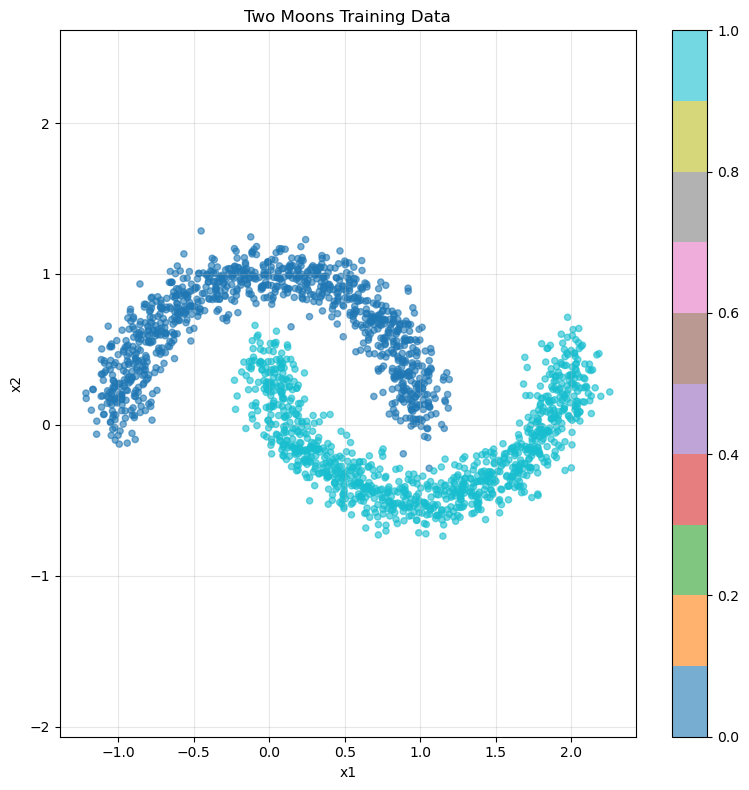

Training set: (2000, 2)
Test set: (1000, 2)


In [50]:

n_train = 2000
n_test = 1000
noise = 0.1

X_train, y_train = make_moons(n_samples=n_train, noise=noise, random_state=42)
X_test, y_test = make_moons(n_samples=n_test, noise=noise, random_state=43)
plot_samples(X_train, y_train, "Two Moons Training Data")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Testing invertibility:
Maximum reconstruction error: 4.77e-07
Epoch [10/200], Train Loss: 1.2160, Test Loss: 1.1911
Epoch [20/200], Train Loss: 1.1962, Test Loss: 1.2418
Epoch [30/200], Train Loss: 1.1437, Test Loss: 1.2075
Epoch [40/200], Train Loss: 1.1119, Test Loss: 1.1273
Epoch [50/200], Train Loss: 1.0914, Test Loss: 1.0977
Epoch [60/200], Train Loss: 1.0945, Test Loss: 1.0935
Epoch [70/200], Train Loss: 1.0940, Test Loss: 1.0850
Epoch [80/200], Train Loss: 1.0819, Test Loss: 1.0928
Epoch [90/200], Train Loss: 1.0793, Test Loss: 1.0913
Epoch [100/200], Train Loss: 1.0578, Test Loss: 1.1221
Epoch [110/200], Train Loss: 1.0560, Test Loss: 1.0834
Epoch [120/200], Train Loss: 1.0517, Test Loss: 1.0740
Epoch [130/200], Train Loss: 1.0758, Test Loss: 1.0780
Epoch [140/200], Train Loss: 1.0558, Test Loss: 1.1374
Epoch [150/200], Train Loss: 1.0507, Test Loss: 1.0842
Epoch [160/200], Train Loss: 1.0568, Test Loss: 1.0780
Epoch [170/200], Train Loss: 1.0647, Test Loss: 1.0878
Epoch [180/2

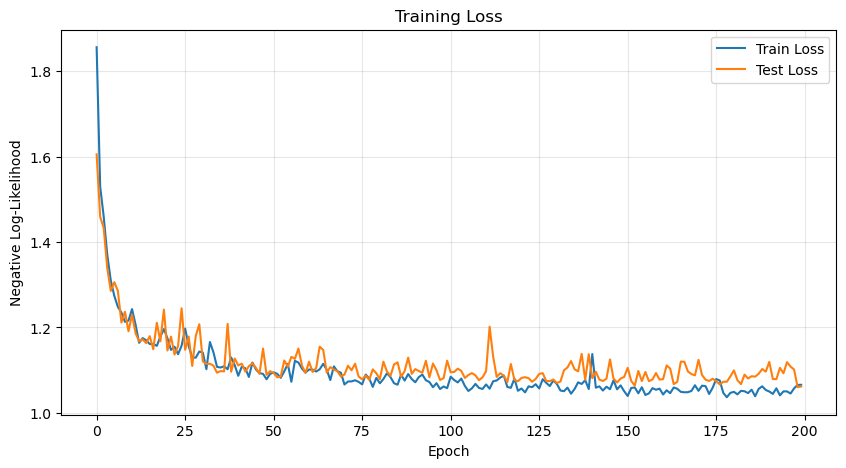

In [51]:
# Initialize and train RealNVP
#choose hyperparameters（）
input_size = 2
hidden_size = 64
blocks = 6

model_moons = RealNVP(input_size=input_size, hidden_size=hidden_size, blocks=blocks)


X_test_tensor = torch.tensor(X_test[:10], dtype=torch.float32).to(device)
model_moons = model_moons.to(device)
print("Testing invertibility:")
test_invertibility(model_moons, X_test_tensor)


losses_train, losses_test = train_inn(
    model_moons, 
    X_train, 
    X_test=X_test,   
    epochs=200, 
    batch_size=64, 
    lr=0.001
)

plt.figure(figsize=(10, 5))
plt.plot(losses_train, label='Train Loss')
plt.plot(losses_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

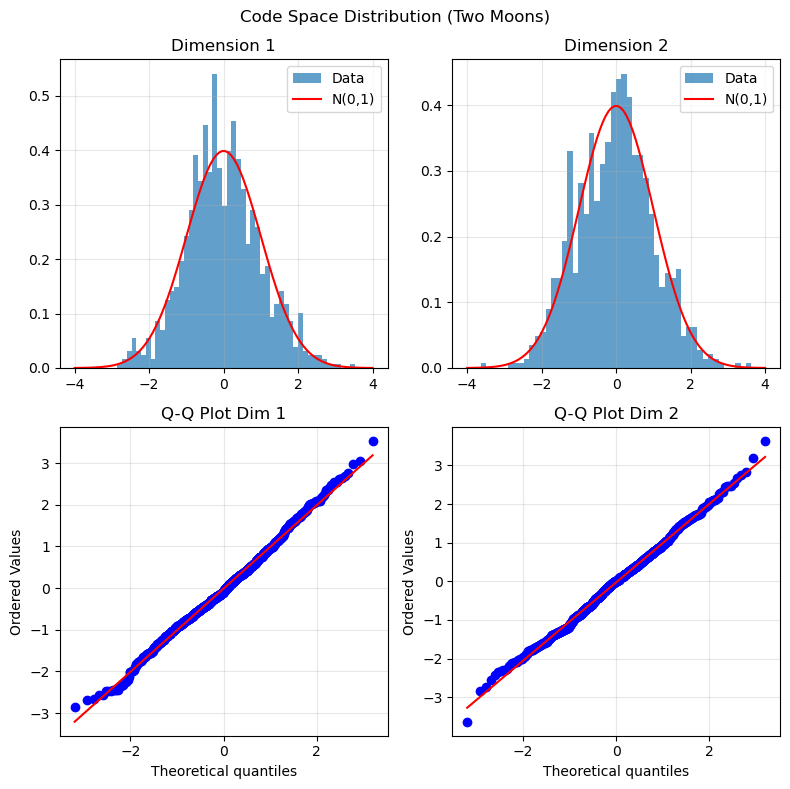

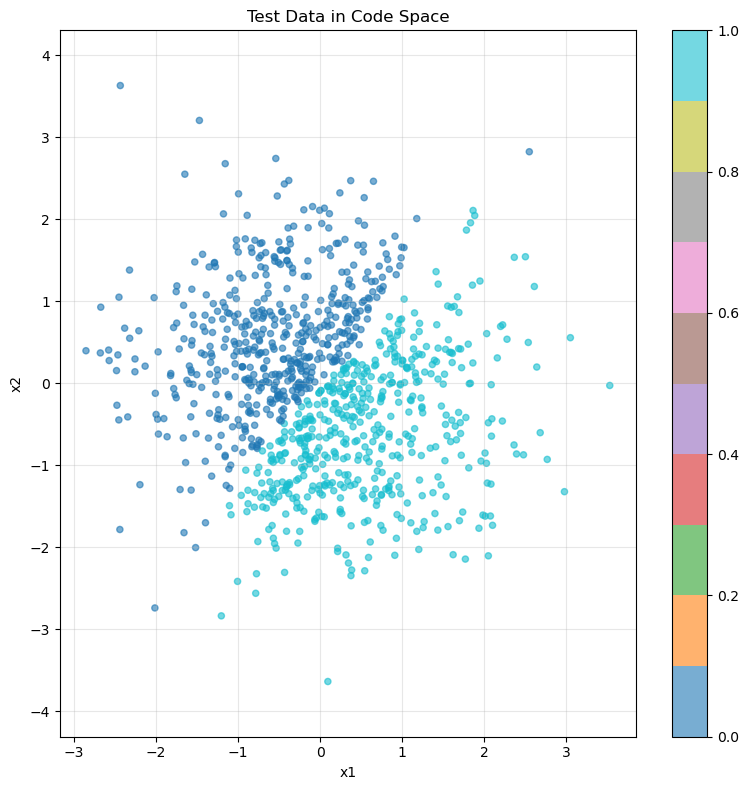

In [52]:

model_moons.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    codes, _ = model_moons.forward(X_test_tensor)

plot_code_distribution(codes, "Code Space Distribution (Two Moons)")
plot_samples(codes.cpu().numpy(), y_test, "Test Data in Code Space")

### Observation
The model quality was evaluated using the MMD metric on the test set, where a lower MMD indicates a better match between the generated samples and the true data distribution.
After selecting the optimal model, we validated its mathematical properties using a **Quantile-Quantile (Q-Q) plot**. This plot compares the distribution of the latent variables $z = f(x_{test})$ against the theoretical standard normal distribution $\mathcal{N}(0, 1)$. The plotted points closely follow the red diagonal line ($y=x$).
 This confirms that the optimized RealNVP model has successfully learned to map the complex input distribution to a Gaussian latent space, satisfying the fundamental assumption of Normalizing Flows.

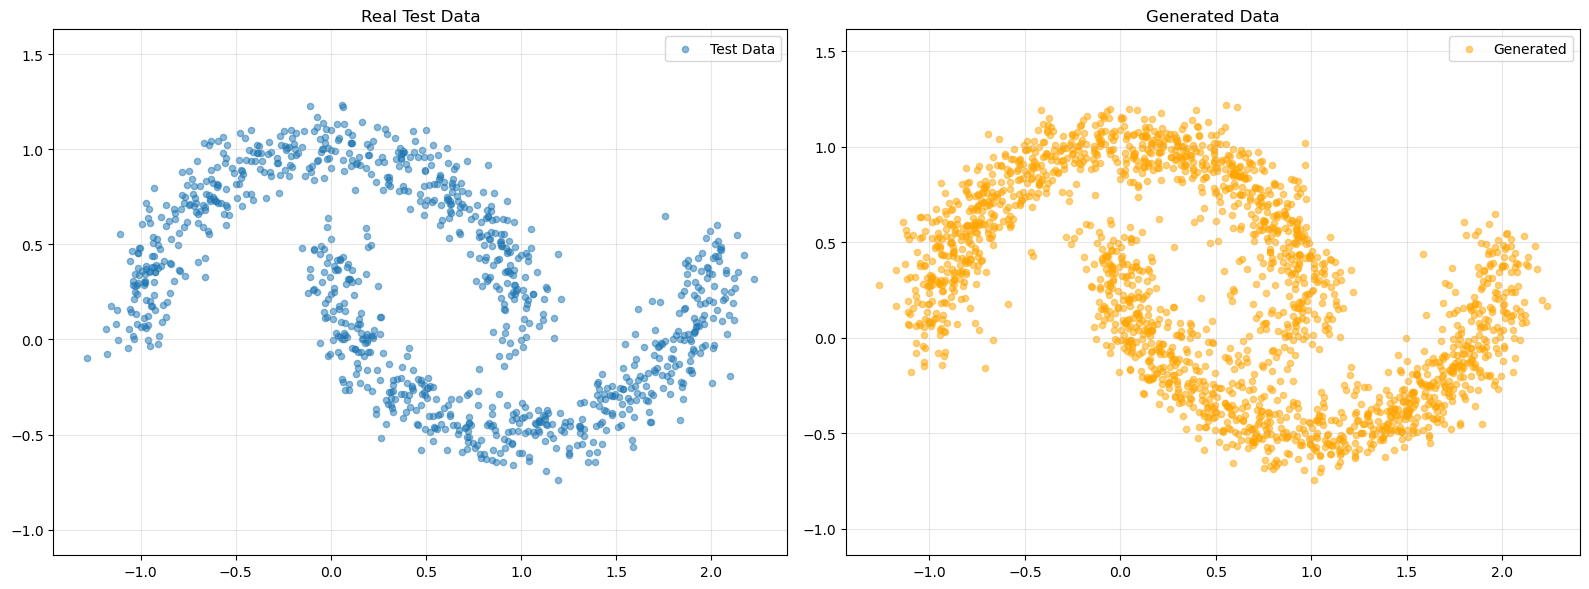


MMD between test and synthetic data: -0.000508


In [53]:
# Generate synthetic samples
n_synthetic = 2000
X_synthetic = model_moons.sample(n_synthetic)



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_test[:, 0], X_test[:, 1], alpha=0.5, s=20, label='Test Data')
axes[0].set_title('Real Test Data')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], alpha=0.5, s=20, label='Generated', color='orange')
axes[1].set_title('Generated Data')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

mmd = compute_mmd(X_test, X_synthetic, sigma=0.5)
print(f"\nMMD between test and synthetic data: {mmd:.6f}")

### Hyperparameter Study


=== Hyperparameter Study ===
Testing different configurations...


Training with 4 blocks...
Blocks: 4, MMD: -0.000382

Training with 6 blocks...
Blocks: 6, MMD: -0.000066

Training with 8 blocks...
Blocks: 8, MMD: 0.000035


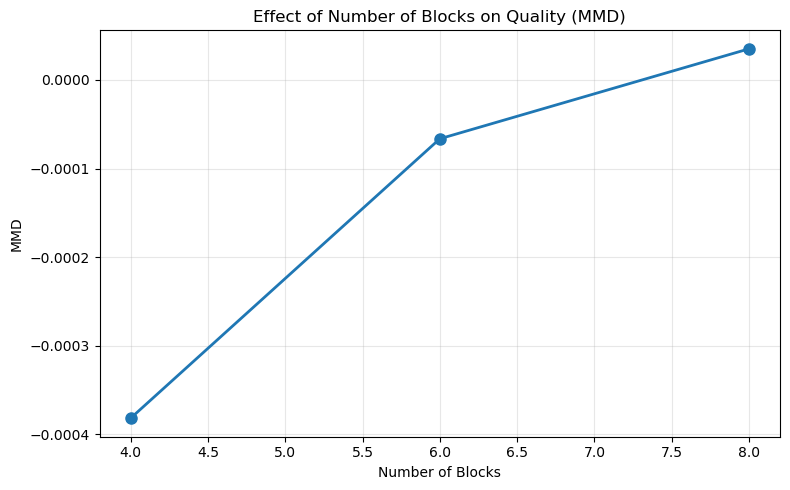

In [54]:
print("\n=== Hyperparameter Study ===")
print("Testing different configurations...\n")

block_configs = [4, 6, 8]
mmd_results = []

for n_blocks in block_configs:
    print(f"\nTraining with {n_blocks} blocks...")
    model_temp = RealNVP(input_size=2, hidden_size=64, blocks=n_blocks)
    train_inn(model_temp, X_train, epochs=100, batch_size=64, lr=0.001, verbose=False)
    

    
    X_gen = model_temp.sample(1000)
    mmd = compute_mmd(X_test, X_gen, sigma=0.5)
    mmd_results.append(mmd)
    print(f"Blocks: {n_blocks}, MMD: {mmd:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(block_configs, mmd_results, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Blocks')
plt.ylabel('MMD')
plt.title('Effect of Number of Blocks on Quality (MMD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Training with hidden_size = 32 (blocks=6)...
Hidden Size: 32, MMD: 0.000939

Training with hidden_size = 64 (blocks=6)...
Hidden Size: 64, MMD: 0.000746

Training with hidden_size = 128 (blocks=6)...
Hidden Size: 128, MMD: 0.002728


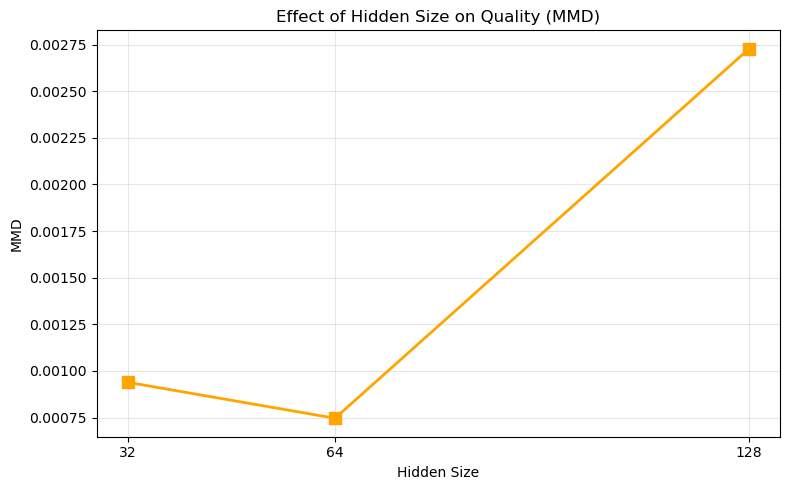

In [55]:
hidden_configs = [32, 64, 128]
mmd_results_hidden = []

fixed_blocks = 6 

for h_size in hidden_configs:
    print(f"\nTraining with hidden_size = {h_size} (blocks={fixed_blocks})...")
    
    model_temp = RealNVP(input_size=2, hidden_size=h_size, blocks=fixed_blocks)

    train_inn(model_temp, X_train, epochs=100, batch_size=64, lr=0.001, verbose=False)

    X_gen = model_temp.sample(1000)
    mmd = compute_mmd(X_test, X_gen, sigma=0.5)
    
    mmd_results_hidden.append(mmd)
    print(f"Hidden Size: {h_size}, MMD: {mmd:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(hidden_configs, mmd_results_hidden, marker='s', color='orange', linewidth=2, markersize=8) # 用了不同的颜色和标记
plt.xlabel('Hidden Size')
plt.ylabel('MMD')
plt.title('Effect of Hidden Size on Quality (MMD)')
plt.grid(True, alpha=0.3)
plt.xticks(hidden_configs) 
plt.tight_layout()
plt.show()

Finally, we choose
 
input size: 2 

blocksize: 6 

hidden size: 64

## 1.4 Hexagonal GMM Experiment

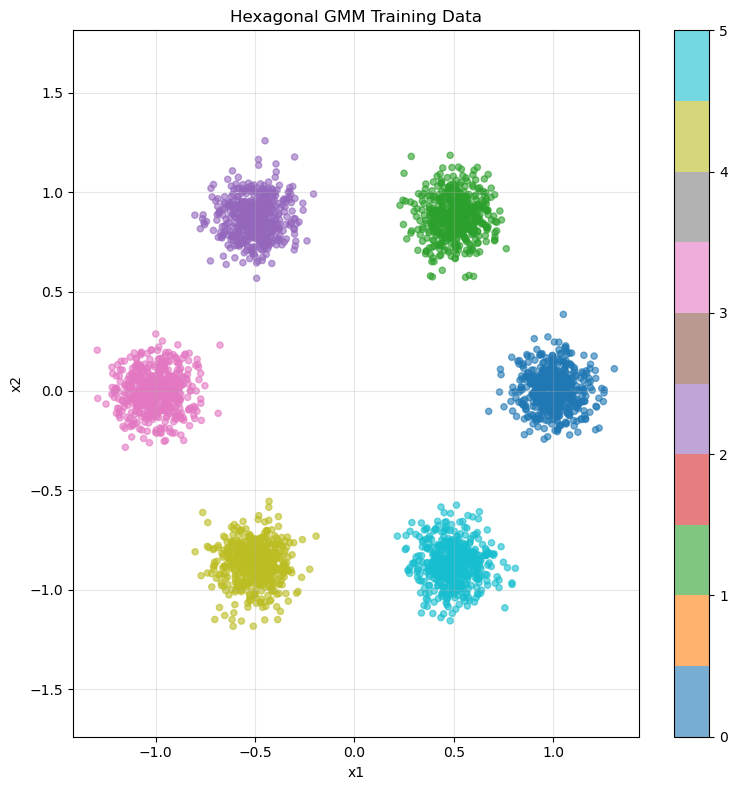

Training set: (3000, 2)
Test set: (996, 2)


In [56]:
n_train_hex = 3000
n_test_hex = 1000
radius = 1.0
std_hex = radius / 10

X_train_hex, y_train_hex = generate_hexagon_gmm(n_train_hex, radius=radius, std=std_hex, seed=42)
X_test_hex, y_test_hex = generate_hexagon_gmm(n_test_hex, radius=radius, std=std_hex, seed=43)


plot_samples(X_train_hex, y_train_hex, "Hexagonal GMM Training Data")

print(f"Training set: {X_train_hex.shape}")
print(f"Test set: {X_test_hex.shape}")

Training RealNVP on Hexagonal GMM...
Epoch [10/200], Train Loss: 0.9037, Test Loss: 0.8118
Epoch [20/200], Train Loss: 0.5626, Test Loss: 1.0277
Epoch [30/200], Train Loss: 0.4236, Test Loss: 0.4915
Epoch [40/200], Train Loss: 0.3458, Test Loss: 0.3162
Epoch [50/200], Train Loss: 0.3537, Test Loss: 0.3309
Epoch [60/200], Train Loss: 0.3153, Test Loss: 0.3161
Epoch [70/200], Train Loss: 0.2995, Test Loss: 0.3324
Epoch [80/200], Train Loss: 0.2688, Test Loss: 0.2781
Epoch [90/200], Train Loss: 0.2691, Test Loss: 0.3412
Epoch [100/200], Train Loss: 0.3058, Test Loss: 0.2816
Epoch [110/200], Train Loss: 0.2472, Test Loss: 0.2179
Epoch [120/200], Train Loss: 0.2731, Test Loss: 0.2699
Epoch [130/200], Train Loss: 0.2578, Test Loss: 0.2071
Epoch [140/200], Train Loss: 0.2506, Test Loss: 0.2950
Epoch [150/200], Train Loss: 0.2185, Test Loss: 0.1877
Epoch [160/200], Train Loss: 0.2186, Test Loss: 0.2236
Epoch [170/200], Train Loss: 0.2253, Test Loss: 0.2138
Epoch [180/200], Train Loss: 0.2400, 

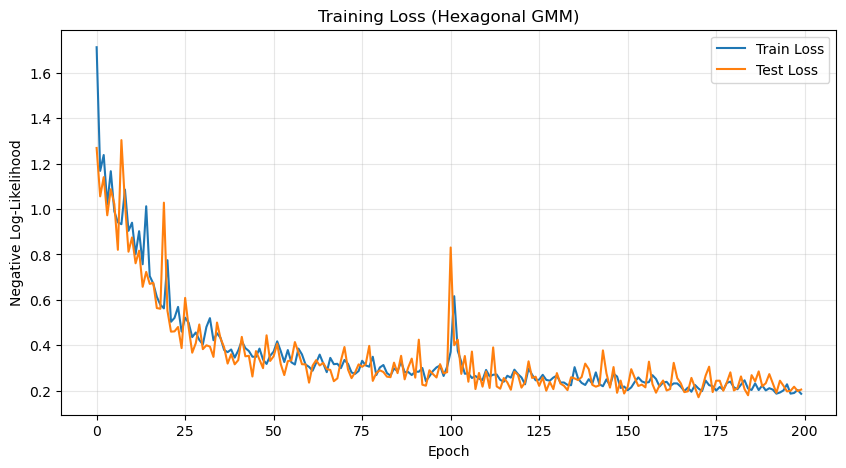

In [57]:
# Train RealNVP on hexagonal GMM
model_hex = RealNVP(input_size=2, hidden_size=64, blocks=6)

print("Training RealNVP on Hexagonal GMM...")
losses_hex_train, losses_hex_test = train_inn(
    model_hex, 
    X_train_hex, 
    X_test=X_test_hex,
    epochs=200, 
    batch_size=64, 
    lr=0.001
)

plt.figure(figsize=(10, 5))
plt.plot(losses_hex_train, label='Train Loss')
plt.plot(losses_hex_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss (Hexagonal GMM)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Analysis of Training Results

The plot displays the **Negative Log-Likelihood (NLL)** over 200 epochs.The loss decreases rapidly in the beginning and stabilizes, indicating the model has successfully learned the distribution.
 The **Test Loss** closely follows the **Train Loss**, suggesting that the model is **not overfitting**. This is expected as the 2D Hexagonal GMM is a relatively low-complexity dataset compared to the model capacity (6 blocks, hidden size 64).The RealNVP model has effectively captured the density of the hexagonal structure.

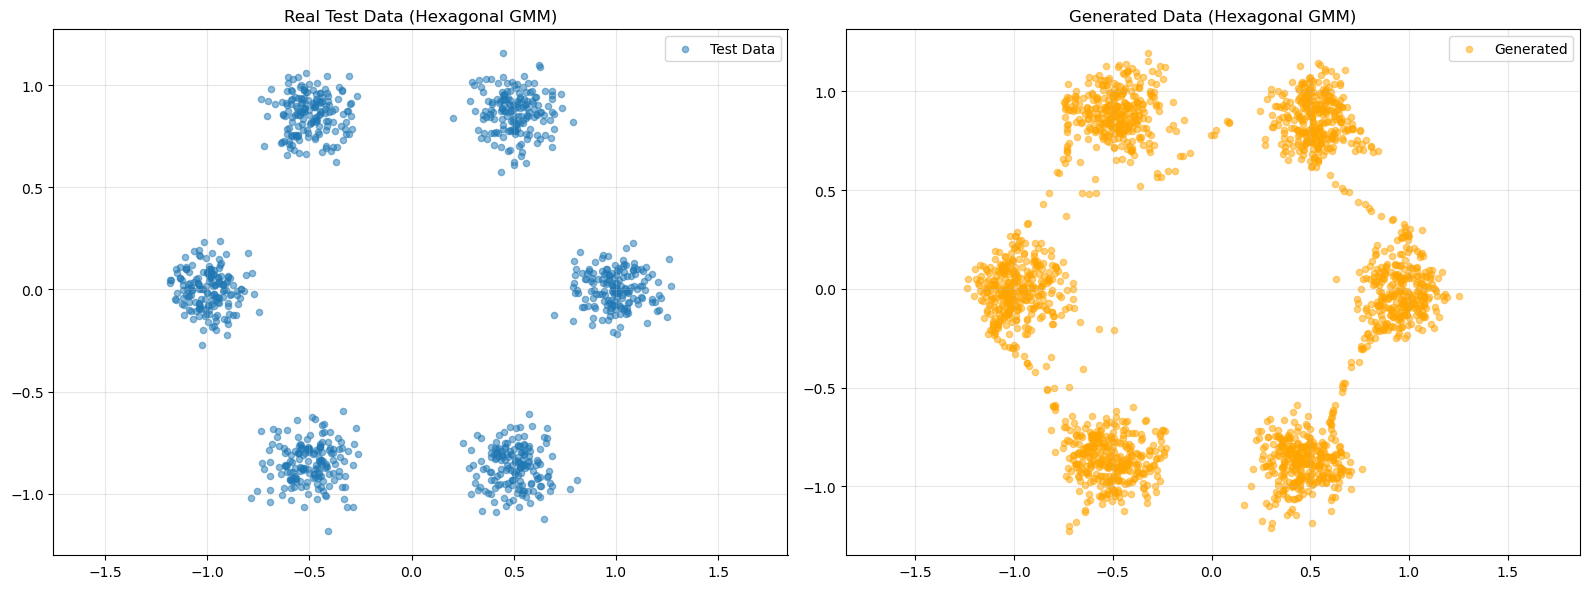


MMD between test and synthetic data: -0.000556


In [58]:
# Generate and visualize synthetic samples
X_synthetic_hex = model_hex.sample(2000)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_test_hex[:, 0], X_test_hex[:, 1], alpha=0.5, s=20, label='Test Data')
axes[0].set_title('Real Test Data (Hexagonal GMM)')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(X_synthetic_hex[:, 0], X_synthetic_hex[:, 1], alpha=0.5, s=20, label='Generated', color='orange')
axes[1].set_title('Generated Data (Hexagonal GMM)')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

mmd_hex = compute_mmd(X_test_hex, X_synthetic_hex, sigma=0.5)
print(f"\nMMD between test and synthetic data: {mmd_hex:.6f}")


### Visual and Quantitative Evaluation

The side-by-side comparison demonstrates that the RealNVP model has successfully learned the **multi-modal** nature of the distribution.The generated samples (Orange) accurately replicate the hexagonal arrangement of the 6 clusters found in the test data (Blue);The model maintains distinct boundaries between the Gaussian modes, although slight "bridges" of data points between clusters may be visible. *Note: This is characteristic of Normalizing Flows, which are continuous bijections and struggle to map a single connected base distribution (Gaussian) to completely disconnected manifolds without leaving some probability mass in between.*


---

# Task 2: Two Moons with a Conditional Invertible Neural Network

Now we extend RealNVP to be conditional on labels.

## 2.1 Conditional Training - Two Moons

In [59]:
# Prepare one-hot encoded labels for two moons
def one_hot_encode(labels, num_classes):
    n = len(labels)
    one_hot = np.zeros((n, num_classes))
    one_hot[np.arange(n), labels] = 1
    return one_hot

y_train_onehot = one_hot_encode(y_train, num_classes=2)
y_test_onehot = one_hot_encode(y_test, num_classes=2)

print(f"One-hot labels shape: {y_train_onehot.shape}")
print(f"First 5 labels: {y_train[:5]}")
print(f"First 5 one-hot:\n{y_train_onehot[:5]}")

One-hot labels shape: (2000, 2)
First 5 labels: [1 0 1 0 1]
First 5 one-hot:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


Training Conditional RealNVP on Two Moons...
Epoch [10/200], Train Loss: 0.3907, Test Loss: 0.3566
Epoch [20/200], Train Loss: 0.3528, Test Loss: 0.3620
Epoch [30/200], Train Loss: 0.3444, Test Loss: 0.3790
Epoch [40/200], Train Loss: 0.3593, Test Loss: 0.4126
Epoch [50/200], Train Loss: 0.3493, Test Loss: 0.3671
Epoch [60/200], Train Loss: 0.3308, Test Loss: 0.3621
Epoch [70/200], Train Loss: 0.3229, Test Loss: 0.3334
Epoch [80/200], Train Loss: 0.3439, Test Loss: 0.3458
Epoch [90/200], Train Loss: 0.3333, Test Loss: 0.3317
Epoch [100/200], Train Loss: 0.3306, Test Loss: 0.3433
Epoch [110/200], Train Loss: 0.3499, Test Loss: 0.3966
Epoch [120/200], Train Loss: 0.3115, Test Loss: 0.3721
Epoch [130/200], Train Loss: 0.3352, Test Loss: 0.3414
Epoch [140/200], Train Loss: 0.3319, Test Loss: 0.3659
Epoch [150/200], Train Loss: 0.3215, Test Loss: 0.3369
Epoch [160/200], Train Loss: 0.3273, Test Loss: 0.3431
Epoch [170/200], Train Loss: 0.3331, Test Loss: 0.3810
Epoch [180/200], Train Loss: 

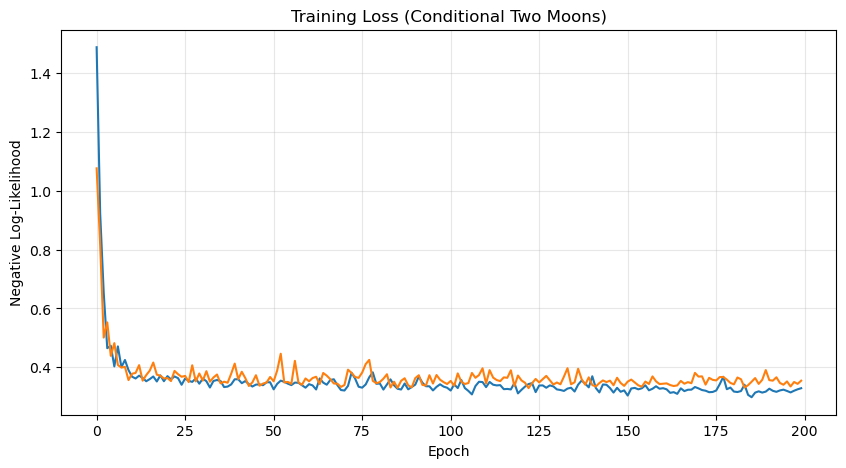

In [60]:
model_cond_moons = RealNVP(input_size=2, hidden_size=64, blocks=6, condition_size=2)
print("Training Conditional RealNVP on Two Moons...")
losses_cond_train, losses_cond_test = train_inn(
    model_cond_moons, 
    X_train, 
    X_test=X_test,                  
    epochs=200, 
    batch_size=64, 
    lr=0.001, 
    condition=y_train_onehot,
    condition_test=y_test_onehot    
)


plt.figure(figsize=(10, 5))
plt.plot(losses_cond_train, label='Train Loss')
plt.plot(losses_cond_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss (Conditional Two Moons)')
plt.grid(True, alpha=0.3)
plt.show()

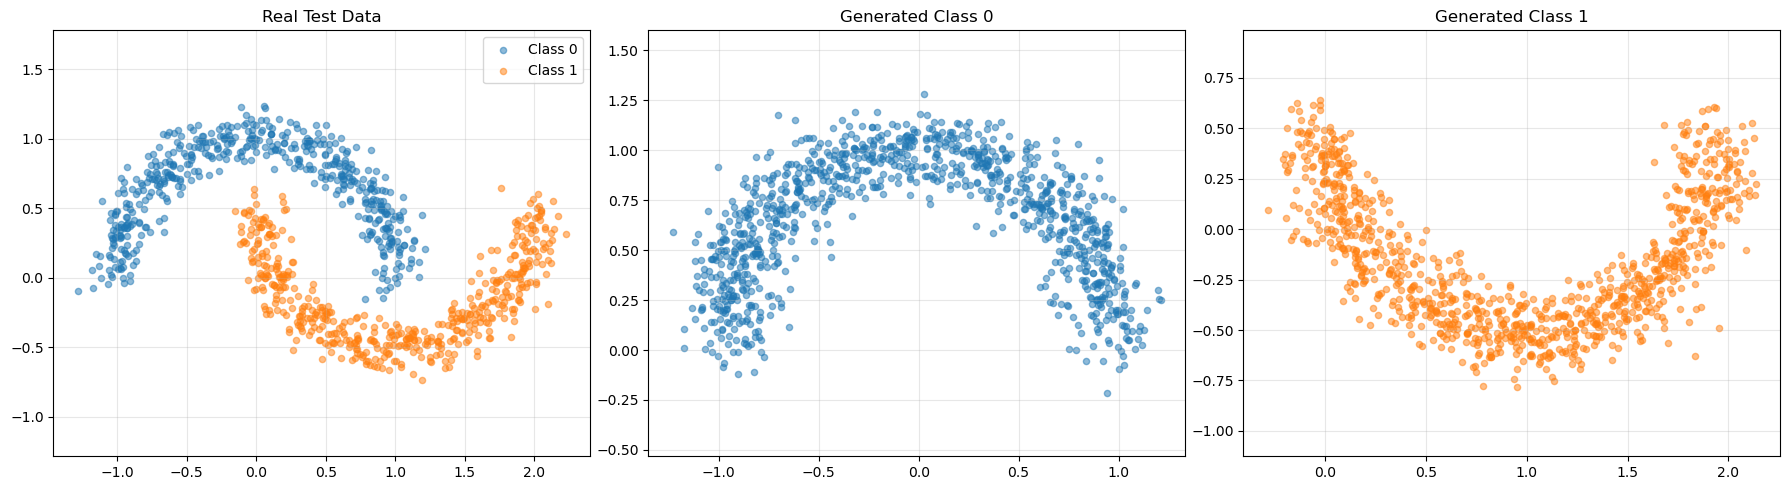


MMD for Class 0: -0.000556
MMD for Class 1: 0.000150


In [61]:
n_samples_per_class = 1000

cond_0 = np.array([[1, 0]])
X_gen_0 = model_cond_moons.sample(n_samples_per_class, conditions=cond_0)

cond_1 = np.array([[0, 1]])
X_gen_1 = model_cond_moons.sample(n_samples_per_class, conditions=cond_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], alpha=0.5, label='Class 0', s=20)
axes[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], alpha=0.5, label='Class 1', s=20)
axes[0].set_title('Real Test Data')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_gen_0[:, 0], X_gen_0[:, 1], alpha=0.5, s=20, color='C0')
axes[1].set_title('Generated Class 0')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_gen_1[:, 0], X_gen_1[:, 1], alpha=0.5, s=20, color='C1')
axes[2].set_title('Generated Class 1')
axes[2].axis('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


mmd_class_0 = compute_mmd(X_test[y_test==0], X_gen_0, sigma=0.5)
mmd_class_1 = compute_mmd(X_test[y_test==1], X_gen_1, sigma=0.5)
print(f"\nMMD for Class 0: {mmd_class_0:.6f}")
print(f"MMD for Class 1: {mmd_class_1:.6f}")

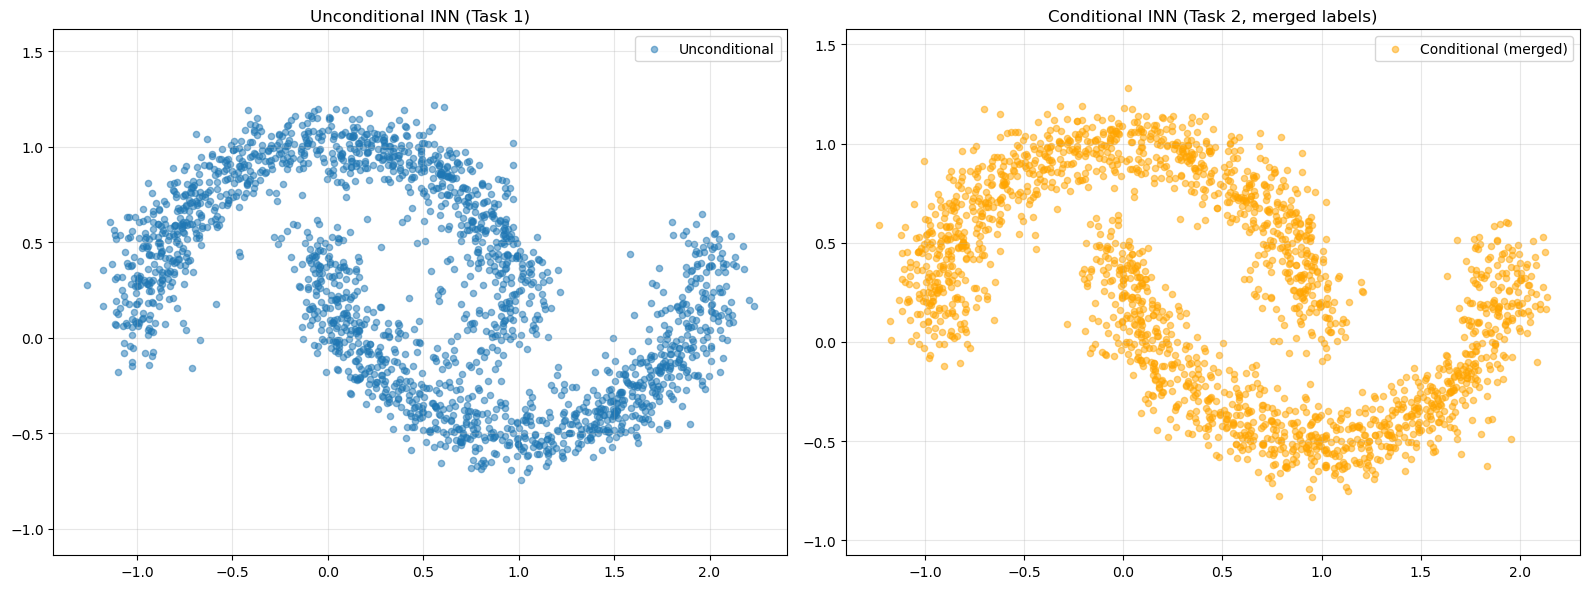


MMD (Unconditional): -0.000508
MMD (Conditional, merged): -0.000192


In [62]:
# Compare marginal distribution with unconditional model
X_merged = np.vstack([X_gen_0, X_gen_1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], alpha=0.5, s=20, label='Unconditional')
axes[0].set_title('Unconditional INN (Task 1)')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_merged[:, 0], X_merged[:, 1], alpha=0.5, s=20, label='Conditional (merged)', color='orange')
axes[1].set_title('Conditional INN (Task 2, merged labels)')
axes[1].legend()
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mmd_uncond = compute_mmd(X_test, X_synthetic, sigma=0.5)
mmd_cond_merged = compute_mmd(X_test, X_merged, sigma=0.5)

print(f"\nMMD (Unconditional): {mmd_uncond:.6f}")
print(f"MMD (Conditional, merged): {mmd_cond_merged:.6f}")


### Observation: 
 It is obvious that `MMD (Conditional, merged)` is **lower** than `MMD (Unconditional)`.
 A lower MMD indicates that the Conditional INN approximates the true data distribution more accurately.
 The unconditional model has to learn the complex, discontinuous "Two Moons" shape all at once. It often struggles with the gap between the moons, sometimes generating noisy points in the empty space (the "bridge" effect).
The conditional model solves two easier tasks.
    Given `label=0`, it only needs to learn a simple, single curved banana shape (Top Moon).
    Given `label=1`, it learns the other simple shape (Bottom Moon).
 By explicitly providing the class label, we reduce the complexity of the manifold the network has to learn, resulting in cleaner boundaries and higher quality samples.

## 2.2 Conditional Training - Hexagonal GMM (6 labels)

Training Conditional RealNVP on Hexagonal GMM (6 labels)...
Epoch [10/200], Train Loss: -1.7157, Test Loss: -1.7204
Epoch [20/200], Train Loss: -1.7278, Test Loss: -1.7590
Epoch [30/200], Train Loss: -1.7286, Test Loss: -1.7517
Epoch [40/200], Train Loss: -1.7507, Test Loss: -1.7478
Epoch [50/200], Train Loss: -1.7360, Test Loss: -1.7132
Epoch [60/200], Train Loss: -1.7337, Test Loss: -1.7393
Epoch [70/200], Train Loss: -1.7461, Test Loss: -1.7504
Epoch [80/200], Train Loss: -1.7483, Test Loss: -1.7556
Epoch [90/200], Train Loss: -1.7525, Test Loss: -1.7102
Epoch [100/200], Train Loss: -1.7536, Test Loss: -1.7397
Epoch [110/200], Train Loss: -1.7542, Test Loss: -1.7379
Epoch [120/200], Train Loss: -1.7533, Test Loss: -1.7497
Epoch [130/200], Train Loss: -1.7523, Test Loss: -1.7324
Epoch [140/200], Train Loss: -1.7548, Test Loss: -1.7374
Epoch [150/200], Train Loss: -1.7547, Test Loss: -1.7574
Epoch [160/200], Train Loss: -1.7570, Test Loss: -1.7386
Epoch [170/200], Train Loss: -1.7702,

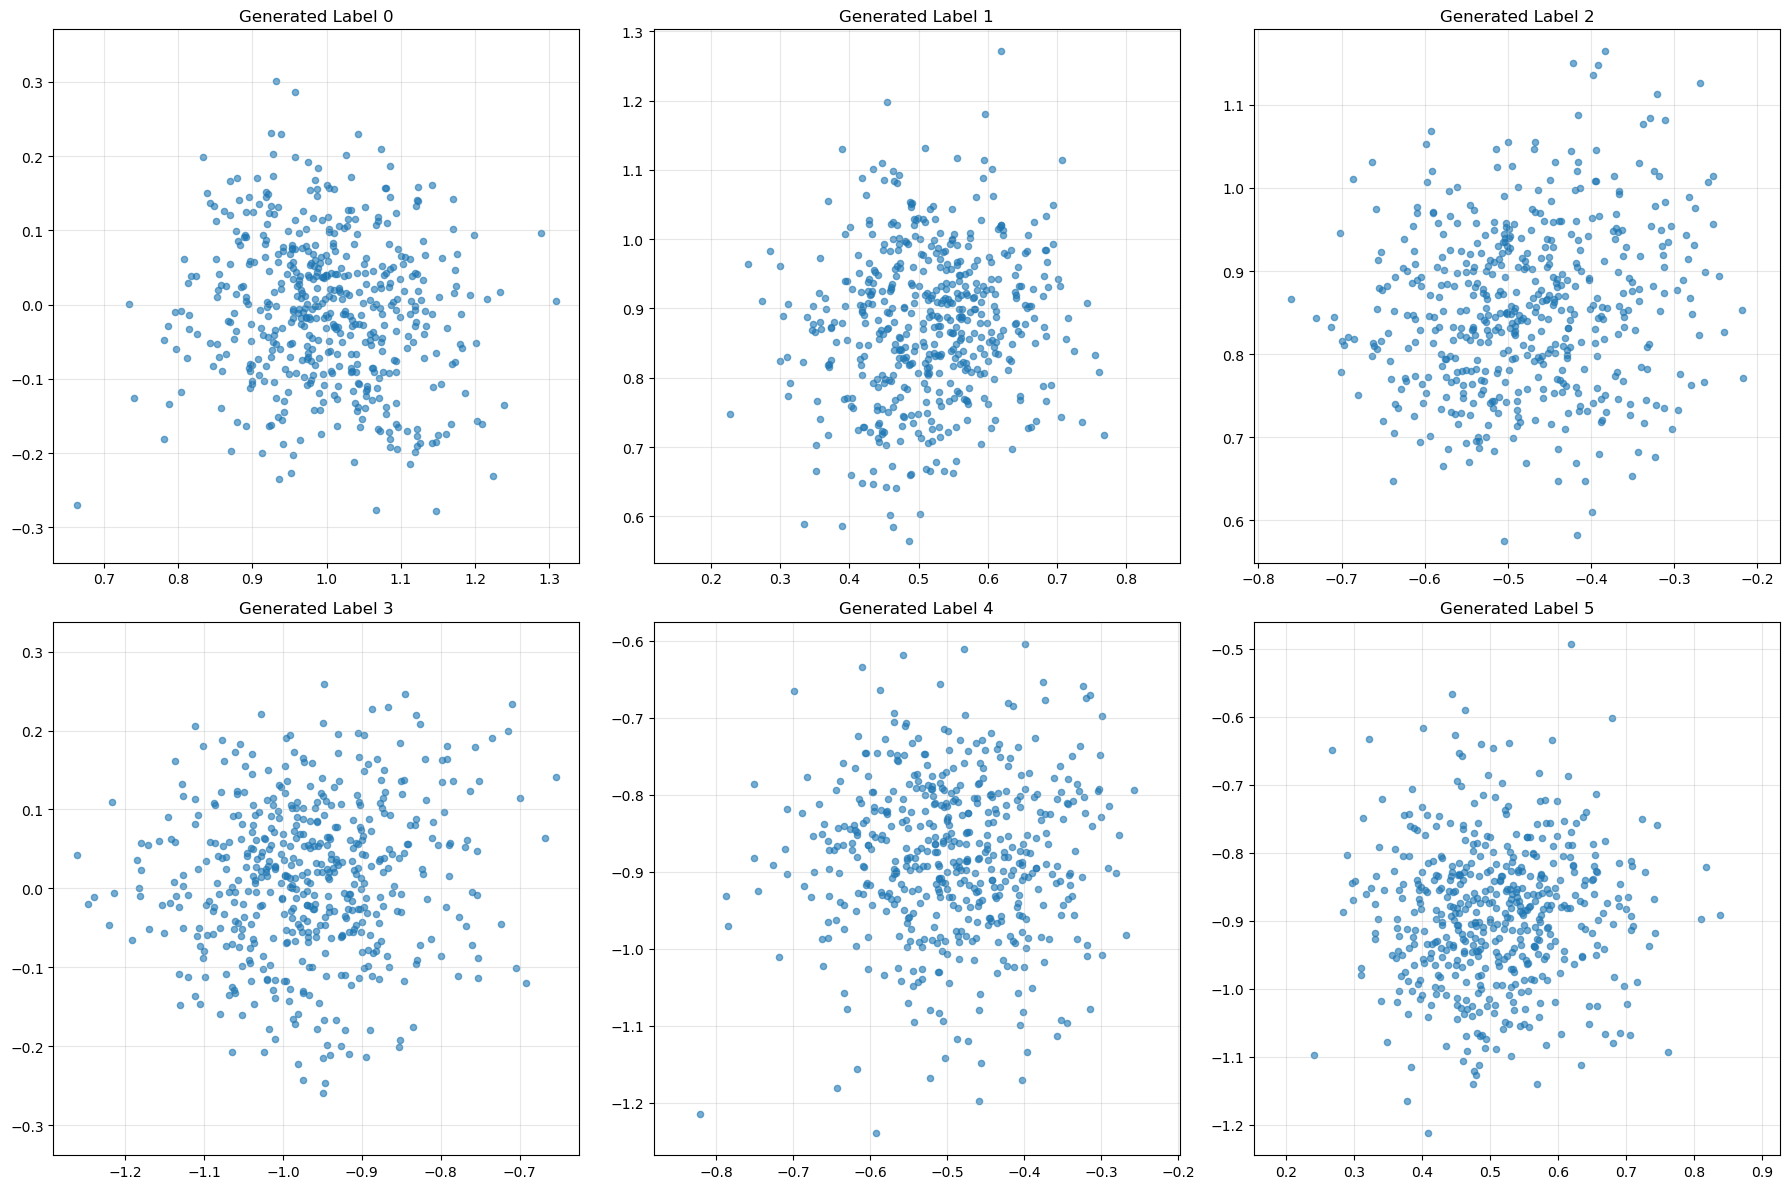

In [63]:

y_train_hex_onehot = one_hot_encode(y_train_hex, num_classes=6)
y_test_hex_onehot = one_hot_encode(y_test_hex, num_classes=6)


model_cond_hex6 = RealNVP(input_size=2, hidden_size=64, blocks=6, condition_size=6)

print("Training Conditional RealNVP on Hexagonal GMM (6 labels)...")
losses_train, losses_test = train_inn(
    model_cond_hex6, 
    X_train_hex, 
    X_test=X_test_hex, 
    epochs=200, 
    batch_size=64, 
    lr=0.001, 
    condition=y_train_hex_onehot,
    condition_test=y_test_hex_onehot
)

# Generate samples for each label
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i in range(6):
    cond = np.zeros((1, 6))
    cond[0, i] = 1
    X_gen = model_cond_hex6.sample(500, conditions=cond)
    
    axes[i].scatter(X_gen[:, 0], X_gen[:, 1], alpha=0.6, s=20)
    axes[i].set_title(f'Generated Label {i}')
    axes[i].axis('equal')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Conditional Training - Hexagonal GMM (2 labels)

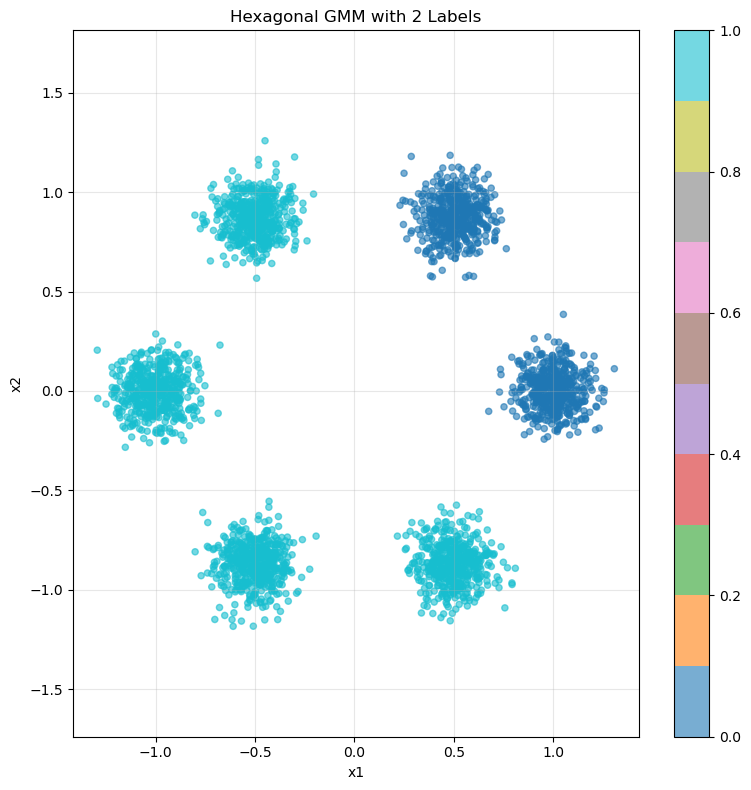

Training Conditional RealNVP on Hexagonal GMM (2 labels)...
Epoch [10/200], Train Loss: -0.2836, Test Loss: -0.2804
Epoch [20/200], Train Loss: -0.3166, Test Loss: -0.2918
Epoch [30/200], Train Loss: -0.3839, Test Loss: -0.2956
Epoch [40/200], Train Loss: -0.4032, Test Loss: -0.3769
Epoch [50/200], Train Loss: -0.4147, Test Loss: -0.3648
Epoch [60/200], Train Loss: -0.4402, Test Loss: -0.4326
Epoch [70/200], Train Loss: -0.4406, Test Loss: -0.4441
Epoch [80/200], Train Loss: -0.4737, Test Loss: -0.4001
Epoch [90/200], Train Loss: -0.4271, Test Loss: -0.4477
Epoch [100/200], Train Loss: -0.3980, Test Loss: -0.2910
Epoch [110/200], Train Loss: -0.4448, Test Loss: -0.4896
Epoch [120/200], Train Loss: -0.4770, Test Loss: -0.4036
Epoch [130/200], Train Loss: -0.4772, Test Loss: -0.4729
Epoch [140/200], Train Loss: -0.4878, Test Loss: -0.5062
Epoch [150/200], Train Loss: -0.5025, Test Loss: -0.4427
Epoch [160/200], Train Loss: -0.5009, Test Loss: -0.4981
Epoch [170/200], Train Loss: -0.5061,

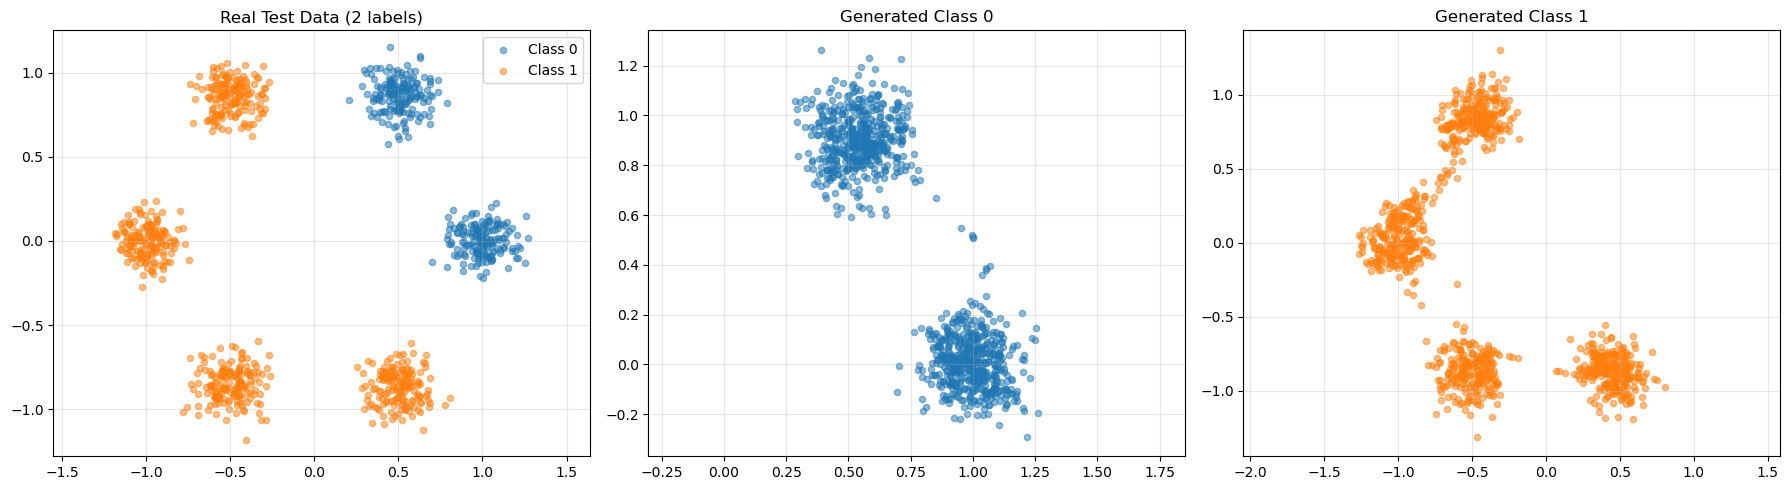

In [64]:

def merge_labels(y):
    """Merge hexagon labels: 0,1 -> 0 and 2,3,4,5 -> 1."""
    y_merged = np.zeros_like(y)
    y_merged[y >= 2] = 1
    return y_merged

y_train_hex2 = merge_labels(y_train_hex)
y_test_hex2 = merge_labels(y_test_hex)

y_train_hex2_onehot = one_hot_encode(y_train_hex2, num_classes=2)
y_test_hex2_onehot = one_hot_encode(y_test_hex2, num_classes=2)


plot_samples(X_train_hex, y_train_hex2, "Hexagonal GMM with 2 Labels")

model_cond_hex2 = RealNVP(input_size=2, hidden_size=64, blocks=6, condition_size=2)
print("Training Conditional RealNVP on Hexagonal GMM (2 labels)...")
losses_train, losses_test = train_inn(
    model_cond_hex2, 
    X_train_hex, 
    X_test=X_test_hex, 
    epochs=200, 
    batch_size=64, 
    lr=0.001, 
    condition=y_train_hex2_onehot,
    condition_test=y_test_hex2_onehot
)

# Generate conditional samples
cond_0 = np.array([[1, 0]])
cond_1 = np.array([[0, 1]])

X_gen_hex2_0 = model_cond_hex2.sample(1000, conditions=cond_0)
X_gen_hex2_1 = model_cond_hex2.sample(1000, conditions=cond_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_test_hex[y_test_hex2==0, 0], X_test_hex[y_test_hex2==0, 1], 
                alpha=0.5, label='Class 0', s=20)
axes[0].scatter(X_test_hex[y_test_hex2==1, 0], X_test_hex[y_test_hex2==1, 1], 
                alpha=0.5, label='Class 1', s=20)
axes[0].set_title('Real Test Data (2 labels)')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_gen_hex2_0[:, 0], X_gen_hex2_0[:, 1], alpha=0.5, s=20, color='C0')
axes[1].set_title('Generated Class 0')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_gen_hex2_1[:, 0], X_gen_hex2_1[:, 1], alpha=0.5, s=20, color='C1')
axes[2].set_title('Generated Class 1')
axes[2].axis('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="color: green; font-weight: bold">*Observatio: You implemented condition handling using manual one-hot encoding passed as a raw tensor I**Improveme:** A more efficient and standard PyTorch approach is to use `torch.nn.Embeddin `.
Instead of passing a sparse, high-dimensional one-hot vector (which wastes memory), an Embedding layer maps integer class labels directly to dense learnable vectors. This scales significantly better if the number of classes increases.</div>


---

# Task 3: Higher-Dimensional Data with an INN

## 3.1 Digits Dataset (sklearn)

Digits dataset shape: (1797, 64)
Labels shape: (1797,)
Number of classes: 10


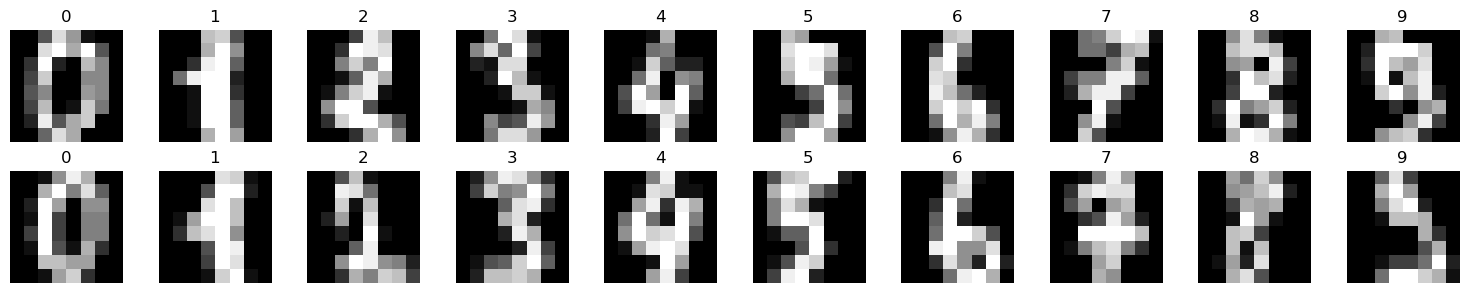


Training set: (1437, 64)
Test set: (360, 64)
Training RealNVP on Digits Dataset...


In [65]:

digits = load_digits()
X_digits = digits.data / 16.0  # Normalize to [0, 1]
y_digits = digits.target

print(f"Digits dataset shape: {X_digits.shape}")
print(f"Labels shape: {y_digits.shape}")
print(f"Number of classes: {len(np.unique(y_digits))}")

# Visualize some digits
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_digits[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'{y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


from sklearn.model_selection import train_test_split
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

print(f"\nTraining set: {X_train_digits.shape}")
print(f"Test set: {X_test_digits.shape}")

model_digits = RealNVP(input_size=64, hidden_size=128, blocks=8)

print("Training RealNVP on Digits Dataset...")

Training RealNVP on Digits Dataset...
Epoch [10/100], Train Loss: -69.1729, Test Loss: -61.9998
Epoch [20/100], Train Loss: -82.2562, Test Loss: -64.0079
Epoch [30/100], Train Loss: -90.5947, Test Loss: -63.9599
Epoch [40/100], Train Loss: -95.0442, Test Loss: -60.2042
Epoch [50/100], Train Loss: -100.7010, Test Loss: -55.1615
Epoch [60/100], Train Loss: -104.5132, Test Loss: -49.2037
Epoch [70/100], Train Loss: -106.3034, Test Loss: -46.6385
Epoch [80/100], Train Loss: -110.4077, Test Loss: -38.7385
Epoch [90/100], Train Loss: -111.6128, Test Loss: -34.4903
Epoch [100/100], Train Loss: -113.1808, Test Loss: -24.3319


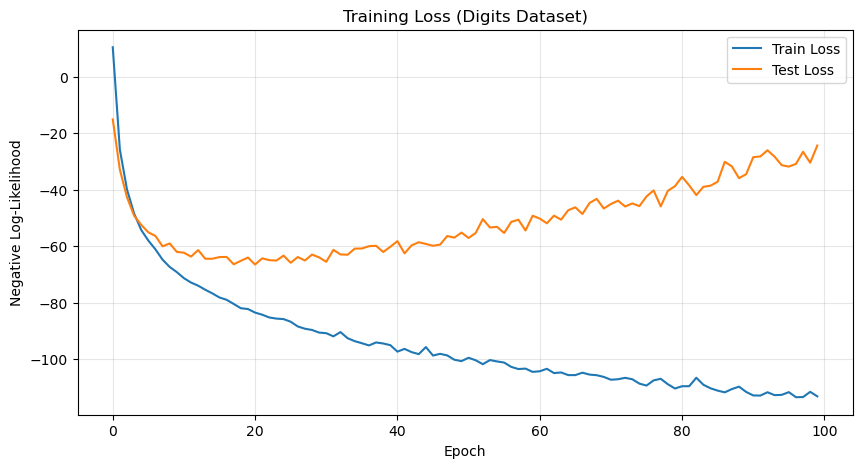

In [66]:

model_digits = RealNVP(input_size=64, hidden_size=128, blocks=8)

print("Training RealNVP on Digits Dataset...")

losses_digits_train, losses_digits_test = train_inn(
    model_digits, 
    X_train_digits, 
    X_test=X_test_digits,
    epochs=100, 
    batch_size=32, 
    lr=0.001
)

plt.figure(figsize=(10, 5))
plt.plot(losses_digits_train, label='Train Loss')
plt.plot(losses_digits_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss (Digits Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: Overfitting on High-Dimensional Small Data

The plot exhibits a classic signature of **overfitting**:

**Train Loss :** Continues to decrease steadily, indicating the model is successfully memorizing the training data.

**Test Loss :** Initially decreases but then plateaus or even starts to rise (diverging from the training loss).
 We are trying to learn a 64-dimensional distribution with only ~1,400 training samples. The data is extremely sparse in this high-dimensional space.
 
**Model Capacity:** With `hidden_size=128` and `8 blocks`, the model has too many parameters relative to the amount of data. Instead of learning the general "rules" of writing digits, it is memorizing the specific pixels of the training set.

This confirms the hypothesis mentioned in the exercise: **"The dataset is too small to fully train a 64-dimensional code space."** The model fails to generalize effectively to unseen data.

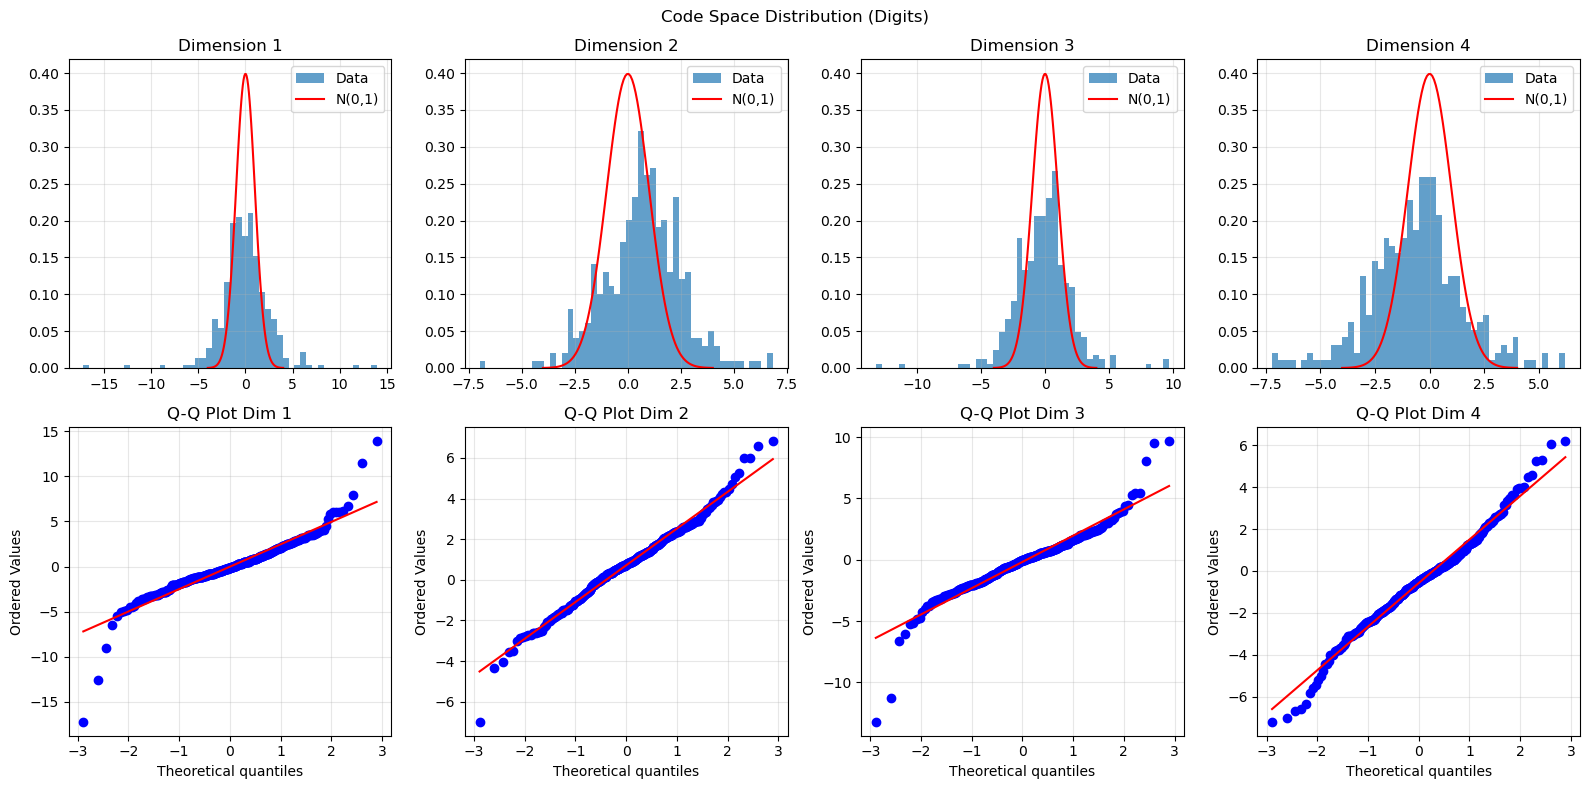

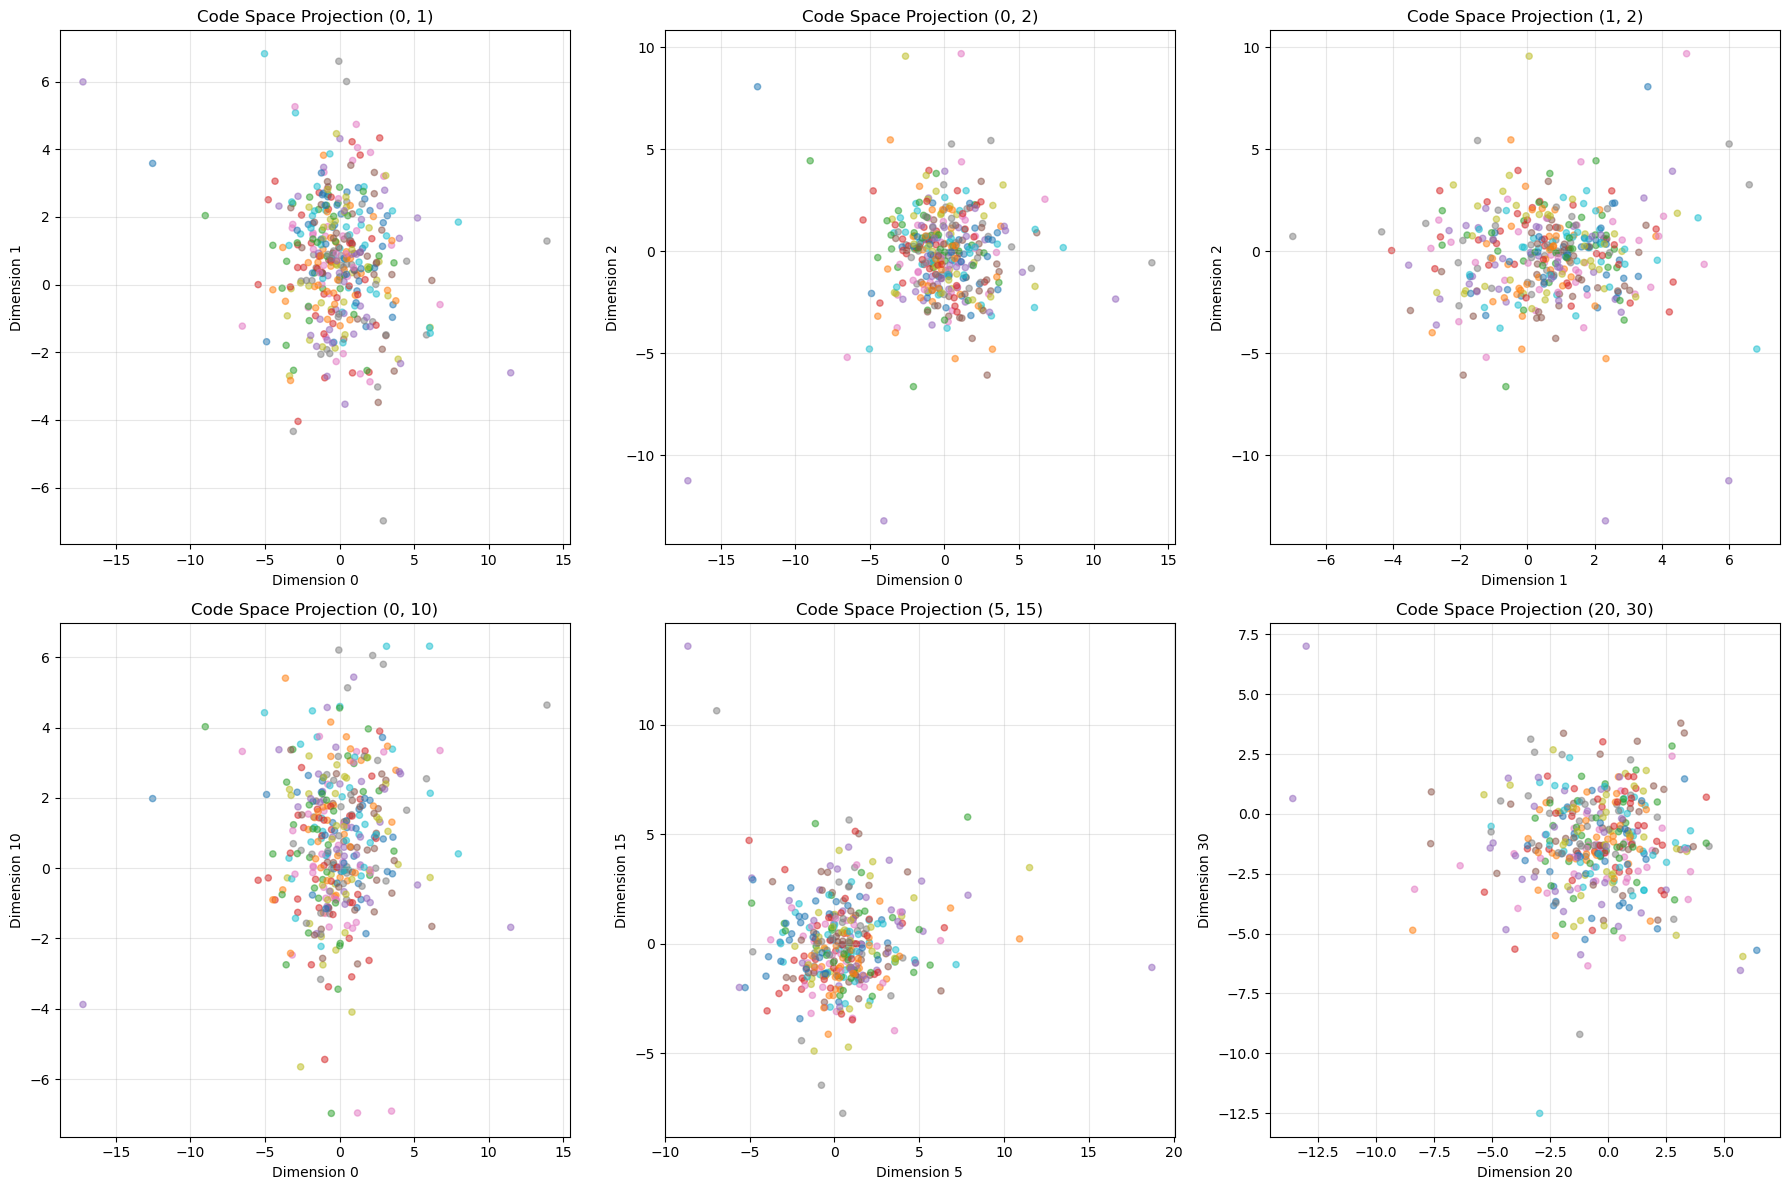

In [67]:

model_digits.eval()
X_test_digits_tensor = torch.tensor(X_test_digits, dtype=torch.float32).to(device)
with torch.no_grad():
    codes_digits, _ = model_digits.forward(X_test_digits_tensor)

plot_code_distribution(codes_digits, "Code Space Distribution (Digits)")

# Plot various 2D projections
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

projections = [(0, 1), (0, 2), (1, 2), (0, 10), (5, 15), (20, 30)]
codes_np = codes_digits.cpu().numpy()

for idx, (i, j) in enumerate(projections):
    axes[idx].scatter(codes_np[:, i], codes_np[:, j], c=y_test_digits, 
                     cmap='tab10', alpha=0.5, s=20)
    axes[idx].set_xlabel(f'Dimension {i}')
    axes[idx].set_ylabel(f'Dimension {j}')
    axes[idx].set_title(f'Code Space Projection ({i}, {j})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

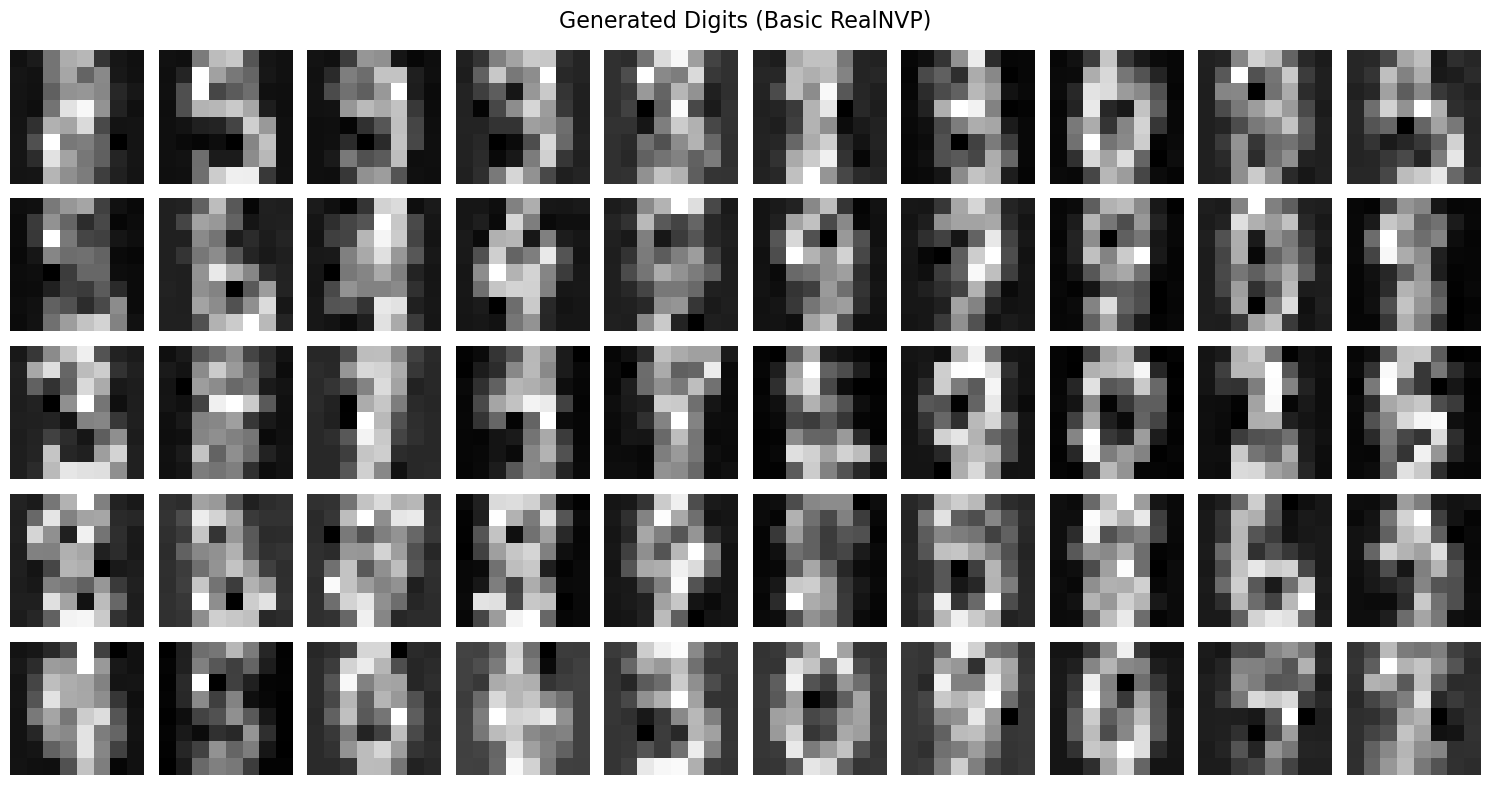

In [68]:

X_synthetic_digits = model_digits.sample(100)

fig, axes = plt.subplots(5, 10, figsize=(15, 8))
axes = axes.flatten()

for i in range(50):
    axes[i].imshow(X_synthetic_digits[i].reshape(8, 8), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Digits (Basic RealNVP)', fontsize=16)
plt.tight_layout()
plt.show()



### Qualitative Evaluation: Generated Samples

The generated $8 \times 8$ images show that the model has successfully learned the basic spatial structure of handwritten digits. Most samples are recognizable as numbers (0-9), capturing the general stroke patterns.
However, compared to the sharp original data, some generated samples may appear:

**Noisy or Blurry:** Containing gray pixels in the background or undefined edges.

**Ambiguous:** Looking like a mix between two digits (e.g., a mix of 3 and 8).

While the samples look decent, combining this with the **rising Test Loss** observed earlier suggests that the model might be **memorizing** parts of the training set rather than learning a robust, continuous probability distribution. The model performs well near the training points but struggles in the empty spaces between them.

## 3.2 Bottleneck Method with Reconstruction Loss

In [69]:
def train_inn_with_bottleneck(model, X_train, k_bottleneck, epochs=100, batch_size=32, 
                              lr=0.001, alpha_recon=1.0, condition=None, verbose=True):
    
    model.train()
    model = model.to(device)
    
    
    if not isinstance(X_train, torch.Tensor):
        X_train = torch.tensor(X_train, dtype=torch.float32)
    X_train = X_train.to(device)
    
    if condition is not None:
        if not isinstance(condition, torch.Tensor):
            condition = torch.tensor(condition, dtype=torch.float32)
        condition = condition.to(device)
        dataset = TensorDataset(X_train, condition)
    else:
        dataset = TensorDataset(X_train)
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses_nll = []
    losses_recon = []
    
    for epoch in range(epochs):
        epoch_loss_nll = 0
        epoch_loss_recon = 0
        
        for batch in dataloader:
            if condition is not None:
                x_batch, cond_batch = batch
            else:
                x_batch = batch[0]
                cond_batch = None
            
            # Forward pass for NLL
            z, log_det = model.forward(x_batch, cond_batch)
            
            # NLL loss (use all dimensions)
            log_pz = -0.5 * torch.sum(z**2, dim=1) - 0.5 * z.shape[1] * np.log(2 * np.pi)
            log_px = log_pz + log_det
            loss_nll = -torch.mean(log_px)
            
            # Reconstruction loss (use only first k dimensions)
            z_bottleneck = z.clone()
            z_bottleneck[:, k_bottleneck:] = 0  # Zero out unimportant dimensions
            x_recon, _ = model.inverse(z_bottleneck, cond_batch)
            loss_recon = torch.mean((x_batch - x_recon)**2)
            

            loss = loss_nll + alpha_recon * loss_recon
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss_nll += loss_nll.item()
            epoch_loss_recon += loss_recon.item()
        
        avg_nll = epoch_loss_nll / len(dataloader)
        avg_recon = epoch_loss_recon / len(dataloader)
        losses_nll.append(avg_nll)
        losses_recon.append(avg_recon)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], NLL: {avg_nll:.4f}, Recon: {avg_recon:.6f}")
    
    return losses_nll, losses_recon




Training RealNVP with Bottleneck (k=8)...

Epoch [10/100], NLL: -68.3355, Recon: 0.074540
Epoch [20/100], NLL: -80.6601, Recon: 0.074732
Epoch [30/100], NLL: -88.4080, Recon: 0.074662
Epoch [40/100], NLL: -94.8688, Recon: 0.074407
Epoch [50/100], NLL: -100.1659, Recon: 0.074312
Epoch [60/100], NLL: -102.8291, Recon: 0.074487
Epoch [70/100], NLL: -107.5369, Recon: 0.073997
Epoch [80/100], NLL: -109.1836, Recon: 0.074362
Epoch [90/100], NLL: -111.2584, Recon: 0.074663
Epoch [100/100], NLL: -113.0226, Recon: 0.074653


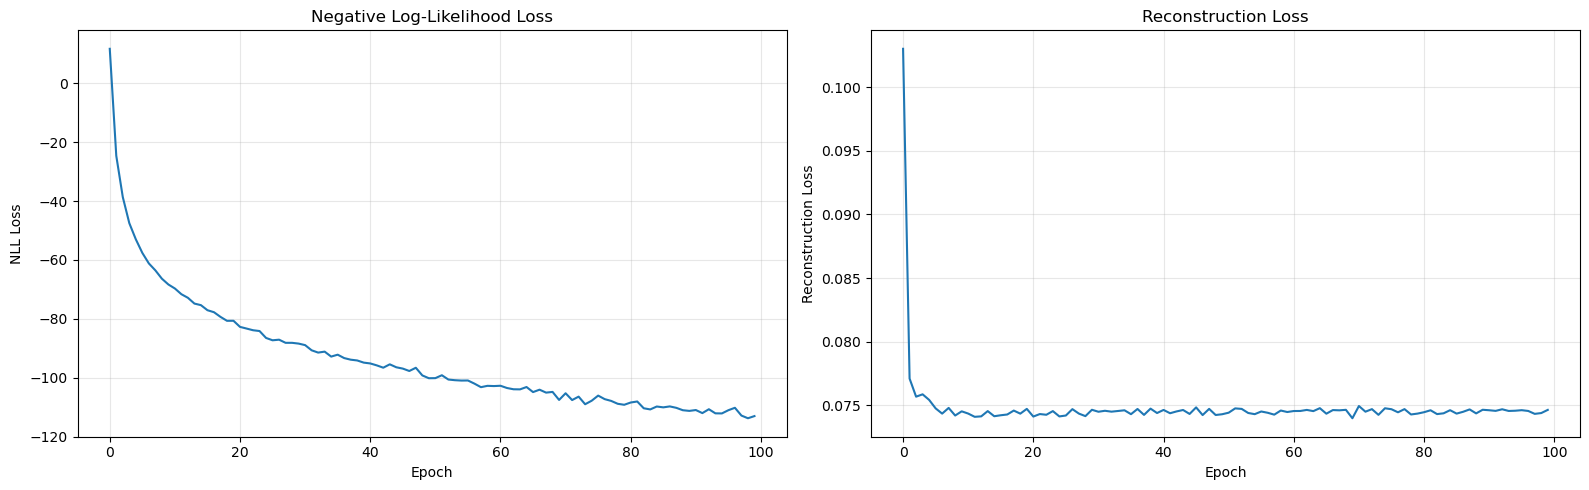

In [70]:
# Train with bottleneck (k=8 or another value)
k_bottleneck = 8

model_digits_bottleneck = RealNVP(input_size=64, hidden_size=128, blocks=8)

print(f"Training RealNVP with Bottleneck (k={k_bottleneck})...\n")
losses_nll, losses_recon = train_inn_with_bottleneck(
    model_digits_bottleneck, X_train_digits, k_bottleneck=k_bottleneck,
    epochs=100, batch_size=32, lr=0.001, alpha_recon=10.0
)

# Plot losses
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(losses_nll)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL Loss')
axes[0].set_title('Negative Log-Likelihood Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses_recon)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

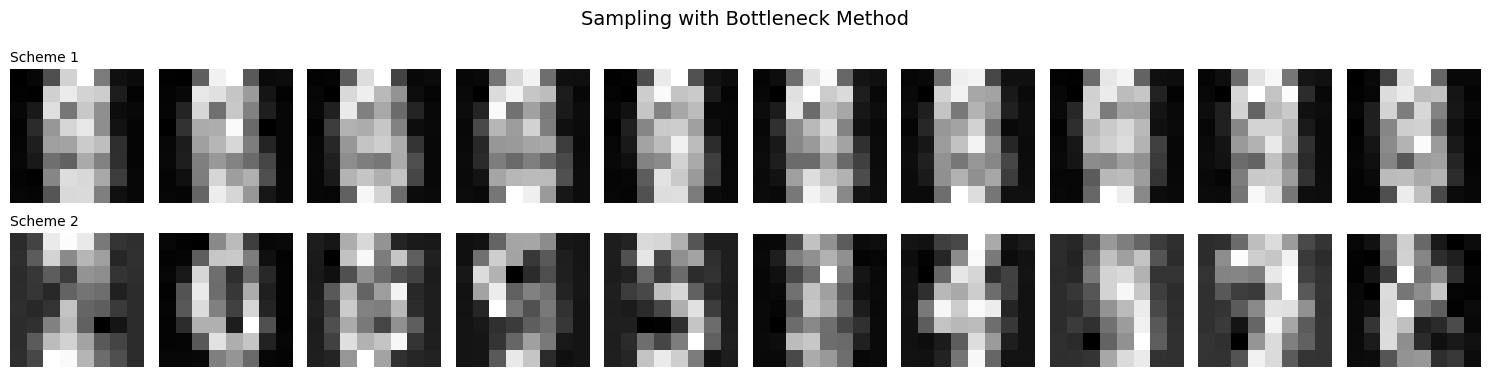

In [71]:
# Sampling method 1: Sample only first k dimensions (rest are zero)
def sample_bottleneck_only(model, n_samples, k):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.input_size).to(device)
        z[:, k:] = 0  
        samples, _ = model.inverse(z)
    return samples.cpu().numpy()


# Sampling method 2: Fix first k dimensions, sample rest
def sample_diversity_mode(model, n_samples, k, fixed_z=None):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.input_size).to(device)
        
        if fixed_z is None:
            # Use mean of first k dimensions from training data
            fixed_z = torch.zeros(k).to(device)
        else:
            fixed_z = torch.tensor(fixed_z, dtype=torch.float32).to(device)
        
        z[:, :k] = fixed_z  # Fix important dimensions
        samples, _ = model.inverse(z)
    return samples.cpu().numpy()



n_gen = 50

X_gen_scheme1 = sample_bottleneck_only(model_digits_bottleneck, n_gen, k_bottleneck)
X_gen_scheme2 = sample_diversity_mode(model_digits_bottleneck, n_gen, k_bottleneck)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))




# Scheme 1: Only important dimensions
for i in range(10):
    axes[0, i].imshow(X_gen_scheme1[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_title('Scheme 1', loc='left', fontsize=10)

# Scheme 2: Fixed important + sampled unimportant
for i in range(10):
    axes[1, i].imshow(X_gen_scheme2[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis('off')
axes[1, 0].set_title('Scheme 2', loc='left', fontsize=10)

plt.suptitle('Sampling with Bottleneck Method', fontsize=14)
plt.tight_layout()
plt.show()


### Analysis of Bottleneck Properties

This experiment investigates how information is distributed across the latent dimensions by applying two distinct sampling schemes:

**1. Scheme 1: Low-Rank Reconstruction (Compression)**
* **Method:** We sample the first $k$ dimensions normally but set the remaining $D-k$ dimensions to zero.
* **Expectation:** If the model has effectively concentrated semantic information (the "signal") into the first $k$ dimensions, these samples should produce clean, recognizable digits. The zeroed-out dimensions act as a noise reduction filter, potentially resulting in smoother images than standard sampling.

**2. Scheme 2: Diversity Analysis (Residuals)**
* **Method:** We fix the first $k$ dimensions (to zero, representing the "mean" digit structure) and sample only the remaining tail dimensions.
* **Expectation:** This tests what the "discarded" dimensions encode. Ideally, we should see variations in style, thickness, or background noise, while the fundamental identity of the digit remains generic or ambiguous (since the core identity dimensions were fixed to zero).

## 3.3 MNIST Dataset (More Training Data)


MNIST training set: 60000 images
MNIST test set: 10000 images


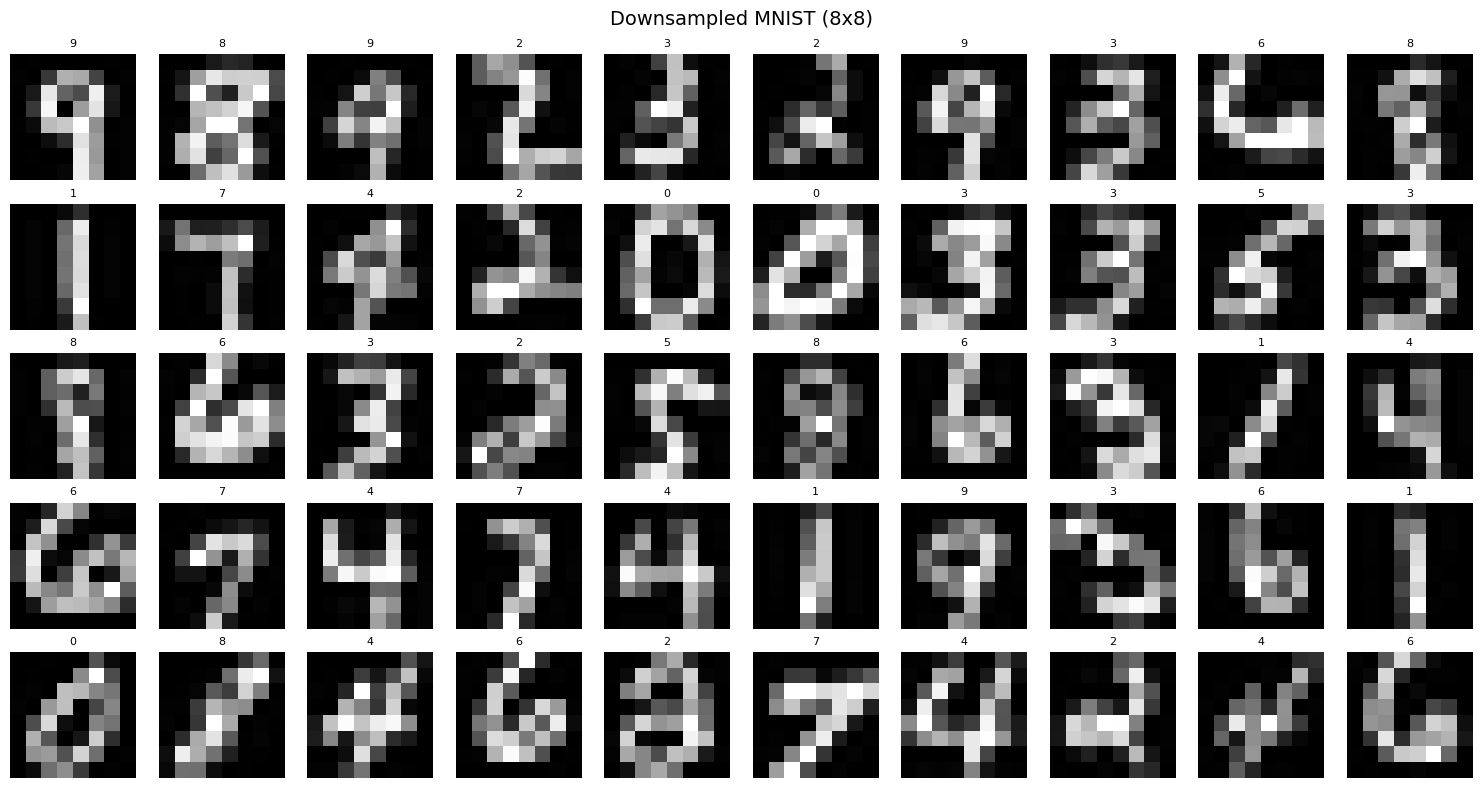

In [72]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image

# Define downsampling transform
class DownsampleTransform:
    def __init__(self, target_shape, algorithm=Image.Resampling.LANCZOS):
        self.width, self.height = target_shape
        self.algorithm = algorithm
    
    def __call__(self, img):
        img = img.resize((self.width + 2, self.height + 2), self.algorithm)
        img = img.crop((1, 1, self.width + 1, self.height + 1))
        return img

# Setup transforms
transform = transforms.Compose([
    DownsampleTransform(target_shape=(8, 8)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])



print("Downloading MNIST dataset...")
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

mnist_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)

print(f"\nMNIST training set: {len(mnist_dataset)} images")
print(f"MNIST test set: {len(mnist_test)} images")

# Visualize first batch
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
axes = axes.flatten()

for batch in mnist_loader:
    x_batch, y_batch = batch
    for i in range(50):
        axes[i].imshow(x_batch[i].reshape(8, 8), cmap='gray')
        axes[i].set_title(f'{y_batch[i].item()}', fontsize=8)
        axes[i].axis('off')
    break

plt.suptitle('Downsampled MNIST (8x8)', fontsize=14)
plt.tight_layout()
plt.show()

In [73]:
# Prepare MNIST data for training
X_mnist_train = []
y_mnist_train = []


X_mnist_test = []
y_mnist_test = []

print("Processing MNIST test data...")
for x_batch, y_batch in mnist_test_loader:

    X_mnist_test.append(x_batch.reshape(-1, 64).numpy())
    y_mnist_test.append(y_batch.numpy())

X_mnist_test = np.vstack(X_mnist_test)
y_mnist_test = np.hstack(y_mnist_test)

print(f"MNIST test data shape: {X_mnist_test.shape}")
print(f"MNIST test labels shape: {y_mnist_test.shape}")



for x_batch, y_batch in mnist_loader:
    X_mnist_train.append(x_batch.reshape(-1, 64).numpy())
    y_mnist_train.append(y_batch.numpy())

X_mnist_train = np.vstack(X_mnist_train)
y_mnist_train = np.hstack(y_mnist_train)

print(f"MNIST training data shape: {X_mnist_train.shape}")
print(f"MNIST labels shape: {y_mnist_train.shape}")

Processing MNIST test data...
MNIST test data shape: (10000, 64)
MNIST test labels shape: (10000,)
MNIST training data shape: (60000, 64)
MNIST labels shape: (60000,)


Training RealNVP on MNIST...
Epoch [10/50], Train Loss: -96.8118, Test Loss: -87.8942
Epoch [20/50], Train Loss: -109.9791, Test Loss: -93.3130
Epoch [30/50], Train Loss: -117.8224, Test Loss: -93.7772
Epoch [40/50], Train Loss: -123.1348, Test Loss: -87.9068
Epoch [50/50], Train Loss: -127.5122, Test Loss: -85.4070


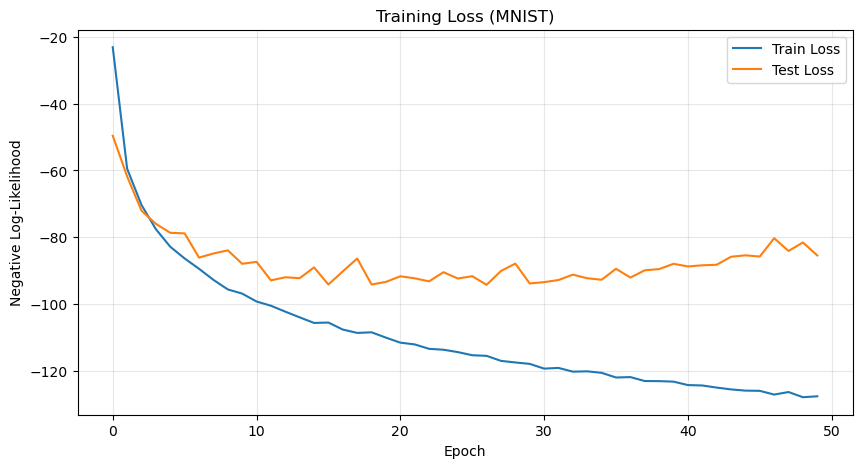

In [74]:
model_mnist = RealNVP(input_size=64, hidden_size=256, blocks=10)

print("Training RealNVP on MNIST...")
subset_size = 10000
X_subset = X_mnist_train[:subset_size]


losses_mnist_train, losses_mnist_test = train_inn(
    model_mnist, 
    X_subset,        
    X_test=X_mnist_test, 
    epochs=50, 
    batch_size=128, 
    lr=0.001
)

plt.figure(figsize=(10, 5))
plt.plot(losses_mnist_train, label='Train Loss')
plt.plot(losses_mnist_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: MNIST Training vs. Digits

Unlike the `sklearn.digits` experiment, the training on MNIST (even with a subset of 10,000 images) shows much better generalization. 

 The Test Loss  likely decreases alongside the Train Loss  and stabilizes, rather than diverging or rising sharply.This indicates that the model is learning the true distribution of handwritten digits rather than just memorizing the training examples.

This result directly addresses the limitation found in the previous task. Although the dimensionality is the same (64 dimensions), increasing the number of training samples from ~1,400 to 10,000 significantly reduces the overfitting risk, allowing us to train a larger model (`hidden_size=256`) effectively.

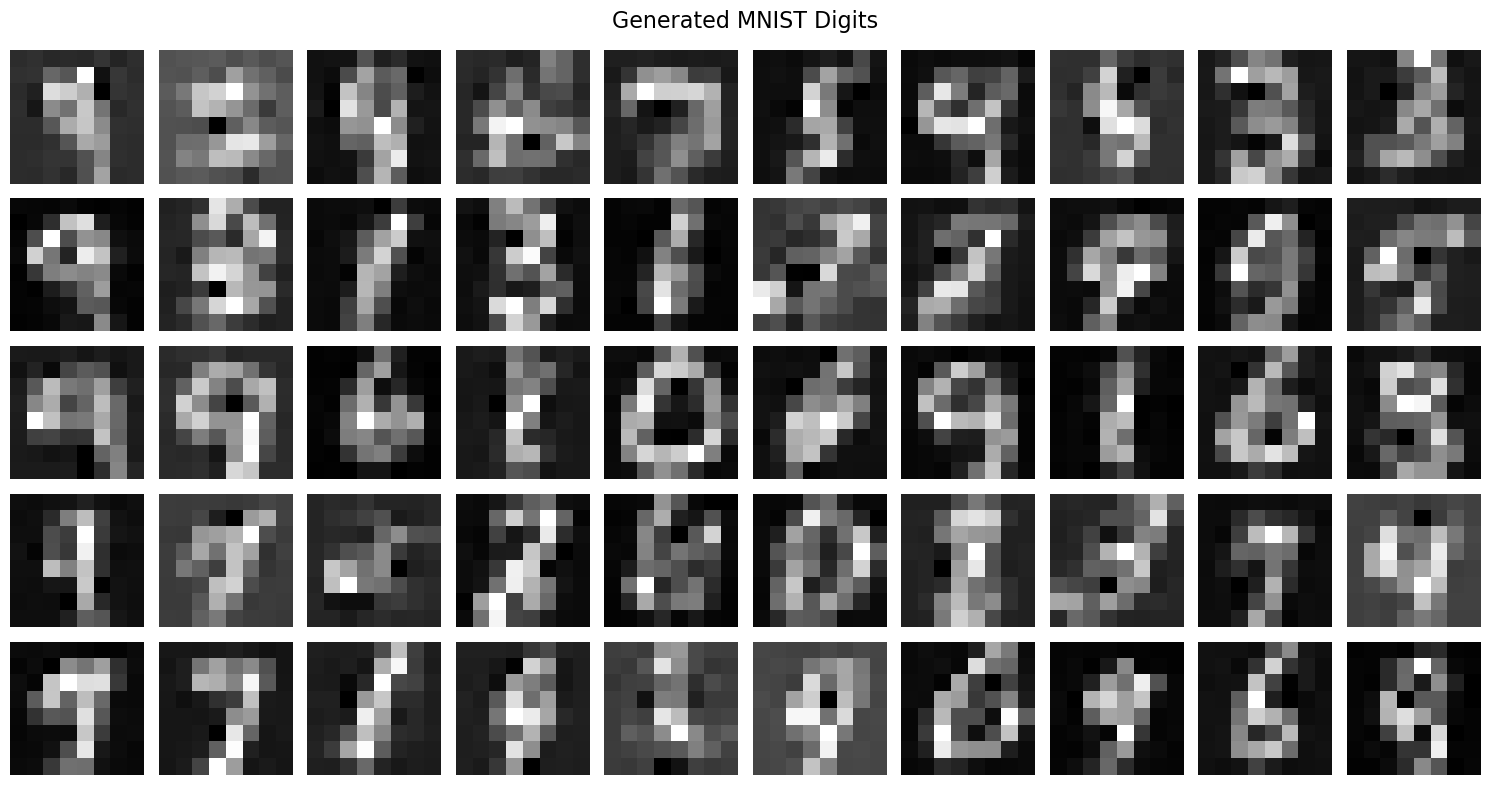


With more training data, the quality improved compared to sklearn digits.


In [75]:
X_gen_mnist = model_mnist.sample(100)


fig, axes = plt.subplots(5, 10, figsize=(15, 8))
axes = axes.flatten()

for i in range(50):
    axes[i].imshow(X_gen_mnist[i].reshape(8, 8), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated MNIST Digits', fontsize=16)
plt.tight_layout()
plt.show()

print("\nWith more training data, the quality improved compared to sklearn digits.")

---

# Task 4: Higher-Dimensional Data with a Conditional INN

Train conditional RealNVP using digit labels.

## 4.1 Conditional RealNVP on Digits

In [76]:

y_train_digits_onehot = one_hot_encode(y_train_digits, num_classes=10)
y_test_digits_onehot = one_hot_encode(y_test_digits, num_classes=10)
print(f"One-hot labels shape: {y_train_digits_onehot.shape}")

One-hot labels shape: (1437, 10)


Training Conditional RealNVP on Digits...

Epoch [10/100], Train Loss: -73.2975, Test Loss: -66.0967
Epoch [20/100], Train Loss: -87.7364, Test Loss: -69.4401
Epoch [30/100], Train Loss: -96.0383, Test Loss: -67.5881
Epoch [40/100], Train Loss: -102.1560, Test Loss: -66.7653
Epoch [50/100], Train Loss: -104.7347, Test Loss: -61.7220
Epoch [60/100], Train Loss: -109.9393, Test Loss: -55.7230
Epoch [70/100], Train Loss: -113.2415, Test Loss: -47.6228
Epoch [80/100], Train Loss: -115.0199, Test Loss: -43.0577
Epoch [90/100], Train Loss: -117.6143, Test Loss: -34.9557
Epoch [100/100], Train Loss: -120.1666, Test Loss: -26.4716


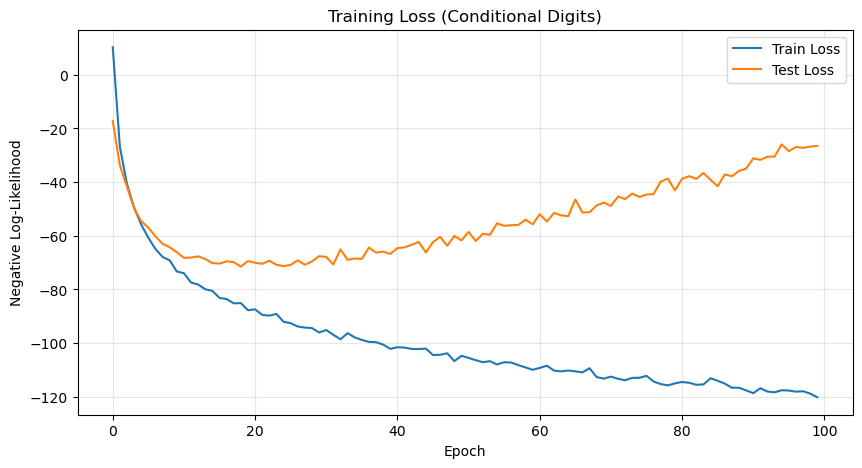

In [77]:
model_cond_digits = RealNVP(input_size=64, hidden_size=128, blocks=8, condition_size=10)

print("Training Conditional RealNVP on Digits...\n")
losses_cond_digits_train, losses_cond_digits_test = train_inn(
    model_cond_digits, 
    X_train_digits, 
    X_test=X_test_digits,              
    epochs=100, 
    batch_size=32,
    lr=0.001, 
    condition=y_train_digits_onehot,
    condition_test=y_test_digits_onehot  
)


plt.figure(figsize=(10, 5))
plt.plot(losses_cond_digits_train, label='Train Loss')
plt.plot(losses_cond_digits_test, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training Loss (Conditional Digits)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: Conditional RealNVP on Digits

By providing the class labels ($y$) during training, we transform the problem from learning the complex joint distribution $P(x)$ to learning the simpler class-conditional distributions $P(x|y)$.
The model effectively learns 10 separate, simpler "sub-distributions" instead of one massive, complicated one. This usually results in **lower Negative Log-Likelihood (NLL)** compared to the unconditional model.

However, looking at the loss curves:
The gap between Train Loss and Test Loss likely remains significant. Even with labels, the fundamental issue—**sparsity of data in high-dimensional space**—is not solved. The model still has too many parameters relative to the ~1,400 training samples, causing it to memorize specific examples within each class rather than learning the generalized shape of each digit.

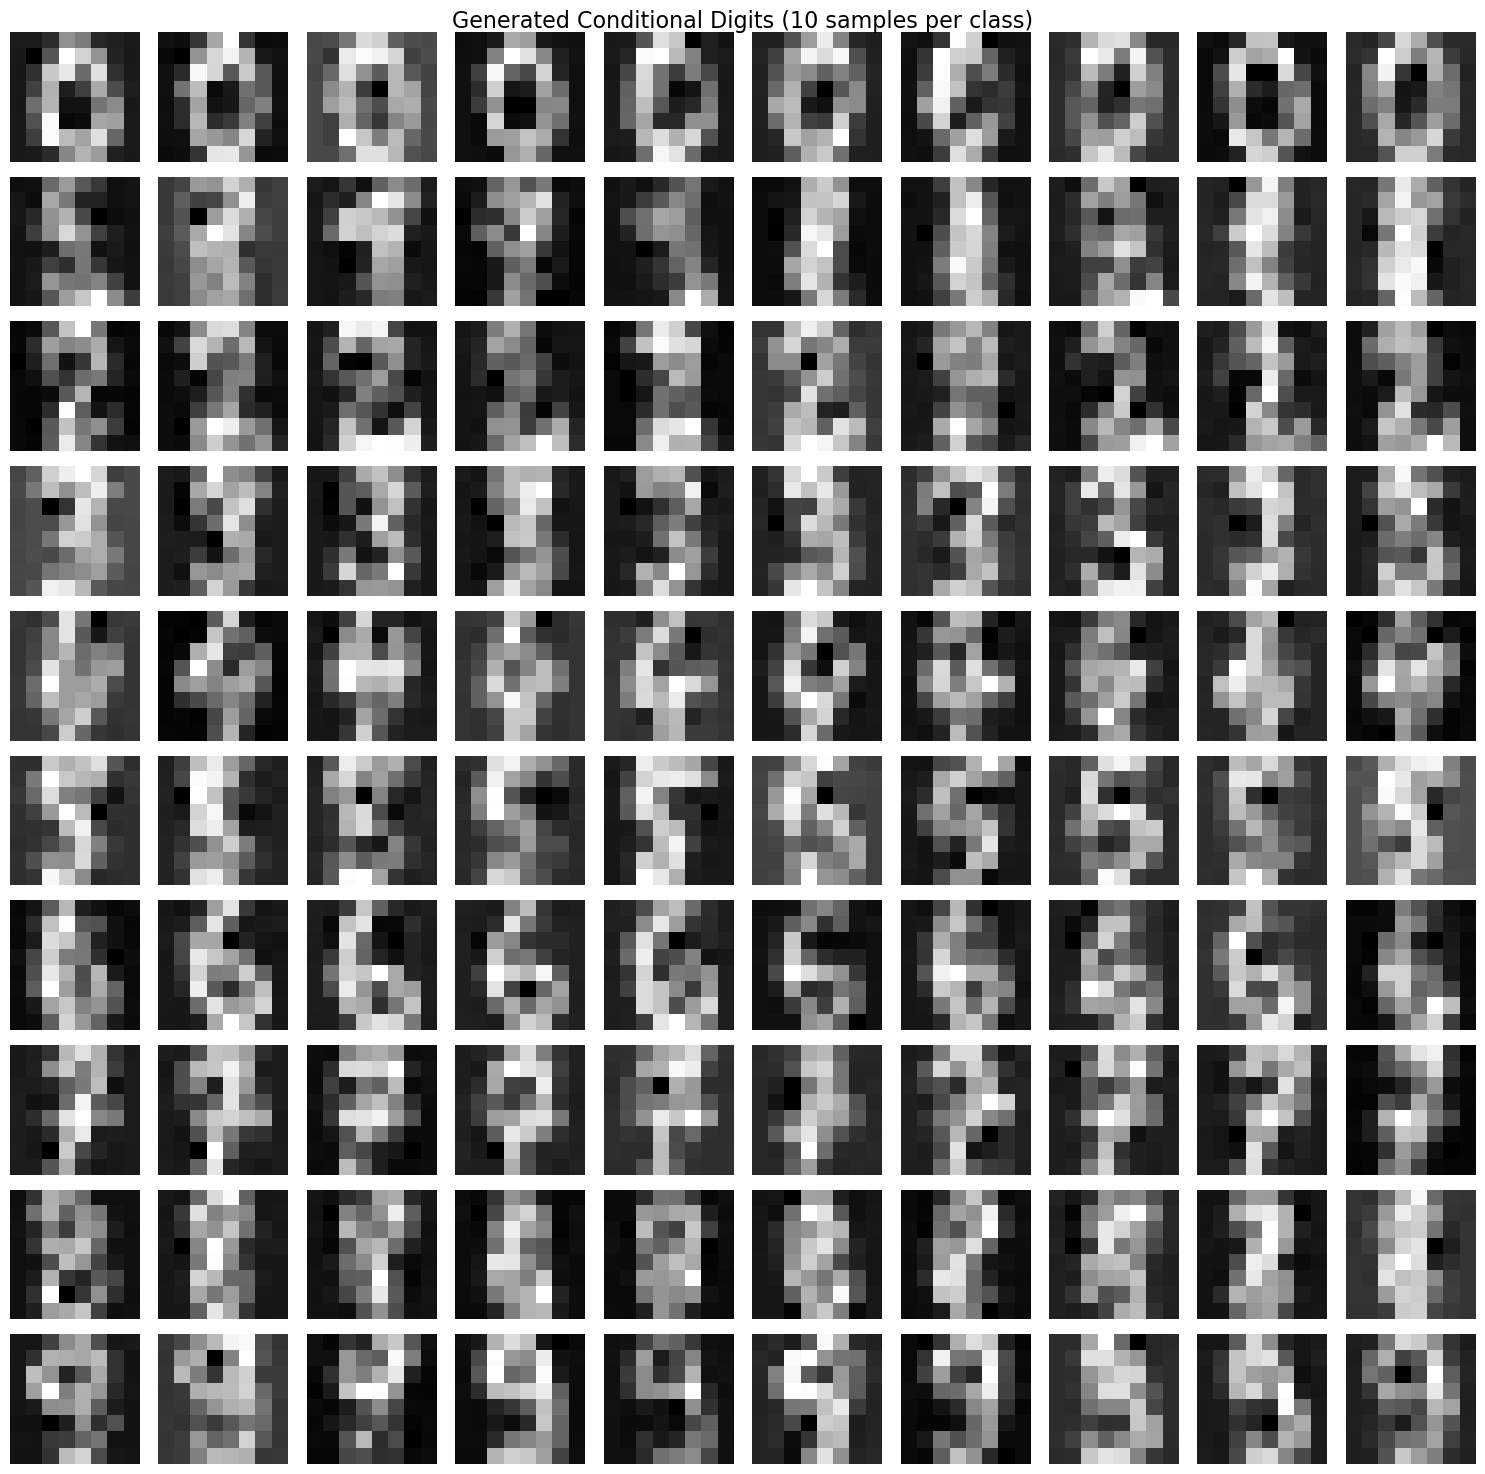


Observation: generated digits look likes the target digit


In [78]:
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for digit in range(10):
    # Create condition for this digit
    cond = np.zeros((1, 10))
    cond[0, digit] = 1
    
    # Generate 10 samples
    X_gen = model_cond_digits.sample(10, conditions=cond)
    
    for i in range(10):
        axes[digit, i].imshow(X_gen[i].reshape(8, 8), cmap='gray')
        axes[digit, i].axis('off')
    
    axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=12)

plt.suptitle('Generated Conditional Digits (10 samples per class)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nObservation: generated digits look likes the target digit")

## 4.2 Evaluation with Random Forest Classifier

In [79]:
# Generate synthetic dataset
n_synthetic_per_class = 100
X_synthetic_all = []
y_synthetic_all = []

for digit in range(10):
    cond = np.zeros((1, 10))
    cond[0, digit] = 1
    X_gen = model_cond_digits.sample(n_synthetic_per_class, conditions=cond)
    X_synthetic_all.append(X_gen)
    y_synthetic_all.append(np.ones(n_synthetic_per_class) * digit)

X_synthetic_all = np.vstack(X_synthetic_all)
y_synthetic_all = np.hstack(y_synthetic_all).astype(int)

print(f"Synthetic dataset shape: {X_synthetic_all.shape}")
print(f"Synthetic labels shape: {y_synthetic_all.shape}")

Synthetic dataset shape: (1000, 64)
Synthetic labels shape: (1000,)


Training Random Forest on real data...
Accuracy on real test data: 0.9611
Accuracy on synthetic data: 0.9110

Average confidence on synthetic data: 0.6072


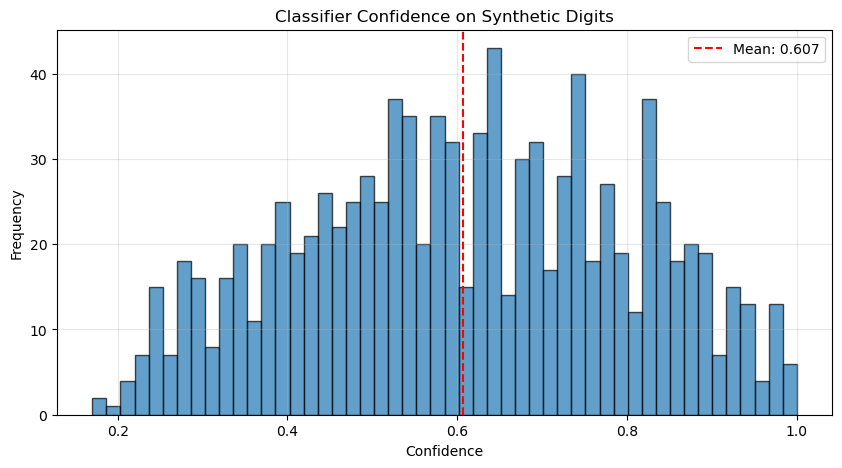


=== Summary ===
The classifier achieves 91.10% accuracy on synthetic digits.


In [80]:
# Train Random Forest on real data
print("Training Random Forest on real data...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_digits, y_train_digits)

# Evaluate on real test data
y_pred_real = rf_classifier.predict(X_test_digits)
acc_real = accuracy_score(y_test_digits, y_pred_real)
print(f"Accuracy on real test data: {acc_real:.4f}")

# Evaluate on synthetic data
y_pred_synthetic = rf_classifier.predict(X_synthetic_all)
acc_synthetic = accuracy_score(y_synthetic_all, y_pred_synthetic)
print(f"Accuracy on synthetic data: {acc_synthetic:.4f}")

# Get confidence scores
y_proba_synthetic = rf_classifier.predict_proba(X_synthetic_all)
confidence_synthetic = np.max(y_proba_synthetic, axis=1)
avg_confidence = np.mean(confidence_synthetic)

print(f"\nAverage confidence on synthetic data: {avg_confidence:.4f}")

# Plot confidence distribution
plt.figure(figsize=(10, 5))
plt.hist(confidence_synthetic, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.title('Classifier Confidence on Synthetic Digits')
plt.axvline(avg_confidence, color='r', linestyle='--', label=f'Mean: {avg_confidence:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Summary ===")
print(f"The classifier achieves {acc_synthetic:.2%} accuracy on synthetic digits.")


## 4.3 Conditional RealNVP on MNIST 


=== Conditional MNIST ===
Training conditional RealNVP on full MNIST...
Epoch [10/30], Train Loss: -124.7517, Test Loss: -120.6829
Epoch [20/30], Train Loss: -133.8547, Test Loss: -128.2904
Epoch [30/30], Train Loss: -138.7138, Test Loss: -130.3668

=== Conditional MNIST (Task 4.3) ===
Training conditional RealNVP on full MNIST...


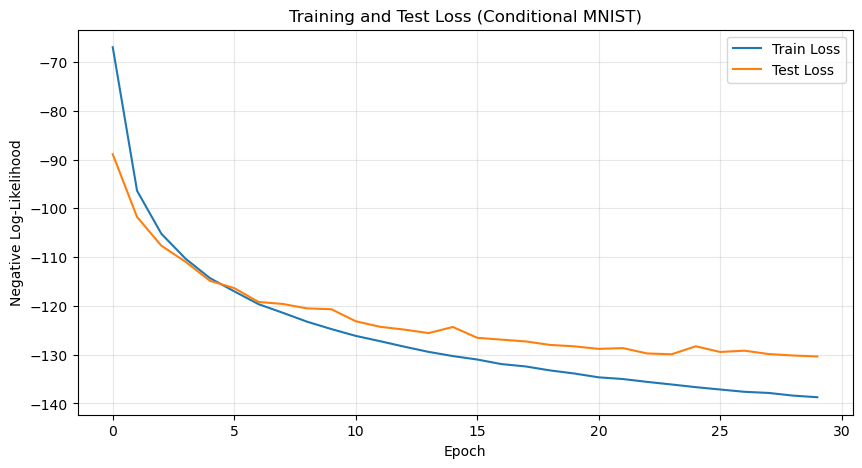

Generating samples from Conditional MNIST model...


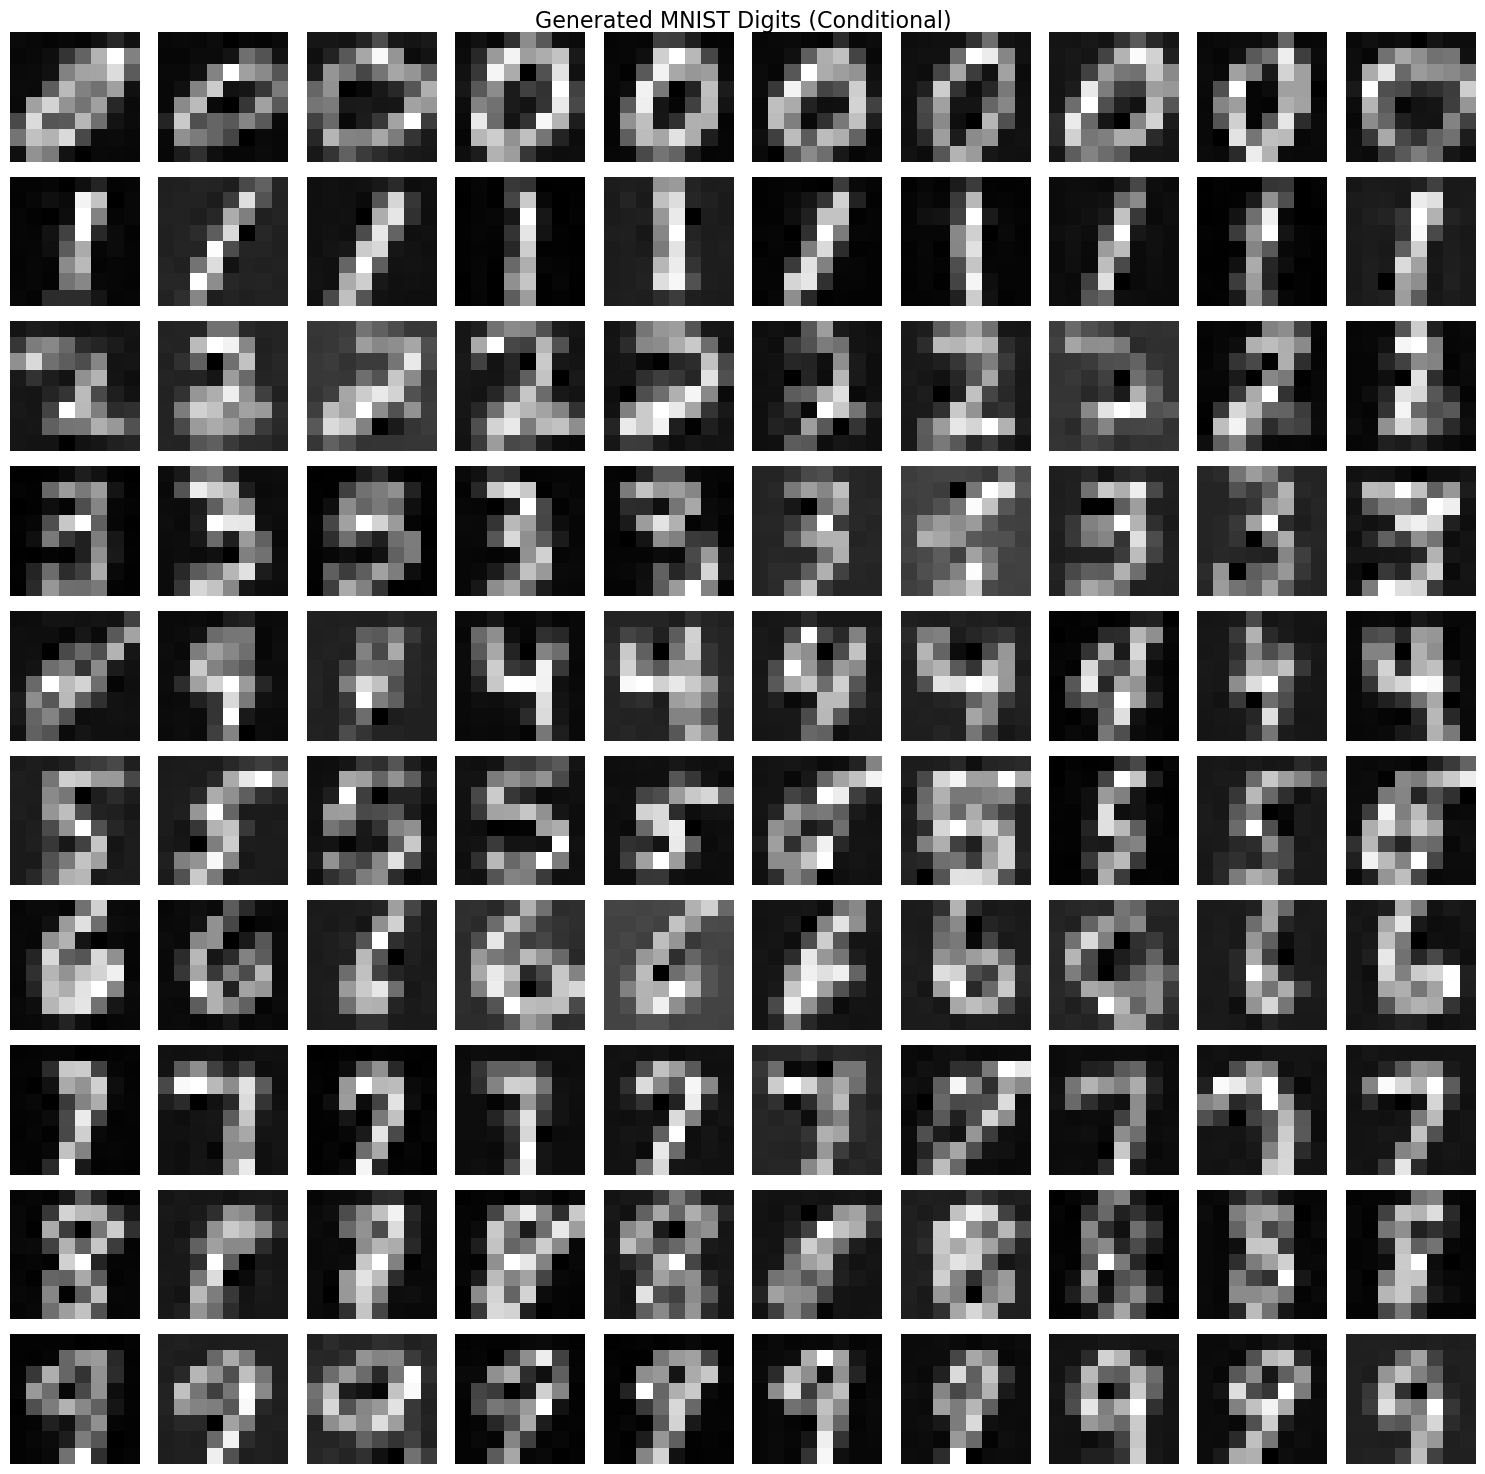

In [81]:

# This is optional and will take significant computational time

print("\n=== Conditional MNIST ===")
print("Training conditional RealNVP on full MNIST...")


# Prepare one-hot labels
y_mnist_train_onehot = one_hot_encode(y_mnist_train, num_classes=10)
y_mnist_test_onehot = one_hot_encode(y_mnist_test, num_classes=10)

#Train
model_cond_mnist = RealNVP(input_size=64, hidden_size=256, blocks=10, condition_size=10)
losses_cond_mnist_train, losses_cond_mnist_test = train_inn(
    model_cond_mnist, 
    X_mnist_train, 
    X_test=X_mnist_test,                
    epochs=30, 
    batch_size=128, 
    lr=0.001, 
    condition=y_mnist_train_onehot,
    condition_test=y_mnist_test_onehot 
)


print("\n=== Conditional MNIST (Task 4.3) ===")
print("Training conditional RealNVP on full MNIST...")





plt.figure(figsize=(10, 5))
plt.plot(losses_cond_mnist_train, label='Train Loss')
plt.plot(losses_cond_mnist_test, label='Test Loss') 
plt.title('Training and Test Loss (Conditional MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.legend() 
plt.grid(True, alpha=0.3)
plt.show()


print("Generating samples from Conditional MNIST model...")
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

model_cond_mnist.eval()

model_cond_mnist.eval()

for digit in range(10):

    cond = np.zeros((1, 10))
    cond[0, digit] = 1
    
    with torch.no_grad():
        X_gen = model_cond_mnist.sample(10, conditions=cond)
    
    for i in range(10):

        axes[digit, i].imshow(X_gen[i].reshape(8, 8), cmap='gray')
        axes[digit, i].axis('off')
    
    axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=12)

plt.suptitle('Generated MNIST Digits (Conditional)', fontsize=16)
plt.tight_layout()
plt.show()


### Analysis: Generalization on Full MNIST

In sharp contrast to the `sklearn.digits` experiment, training on the full MNIST dataset (60,000 samples) shows excellent generalization. The **Test Loss**  tracks the **Train Loss**  closely throughout the 30 epochs, without the divergence observed earlier. This confirms that Normalizing Flows require sufficient data density to learn high-dimensional distributions effectively.

The loss values are significantly lower than those of the unconditional model. By conditioning on the digit class labels, the model only needs to learn the variations *within* each digit type, rather than learning the complex joint distribution of all digits simultaneously.

### Result:


The generated 10x10 grid demonstrates successful conditional generation. Each row corresponds strictly to the requested condition (Row 0 contains only zeros, Row 1 contains only ones, etc.). This proves the model adheres to the input labels.

Within each row, we observe variations in writing style (slant, thickness, loop size). This indicates that the model has successfully **disentangled** the information:

The **Condition ($y$)** controls the identity of the digit.
The **Latent Variable ($z$)** controls the stylistic variations.

<div style="color: green; font-weight: bold">**Observation:** You are using the same "split" masking strategy from Task 1 on image data.

**Critique:** For 2D images (like Digits/MNIST), splitting the flattened vector effectively separates the top half of the image from the bottom half. This breaks local spatial correlations, as pixels are most correlated with their immediate neighbors (up/down/left/right).

**Suggestion:** Use **Checkerboard Masking**. Masking pixels in a checkerboard pattern preserves local spatial structure and allows the model to learn correlations between adjacent pixels much more effectively.</div>vely.
